### <span style = "color:orange">1. Introduction<span>

#### <span style="color:green">1.1. Project purpose</span>

Xây dựng và đánh giá tập hợp các mô hình dự báo chuỗi thời gian để dự đoán nhiệt độ cực đại hàng ngày tại các khu vực đô thị và ven biển Việt Nam. Dự án áp dụng cả thuật toán Machine Learning truyền thống và Deep Learning hiện đại nhằm cải thiện độ chính xác dự báo so với các phương pháp thống kê thông thường.

<b>Nguồn dữ liệu</b>: Bộ dữ liệu ERA5 (ECMWF) với các bản ghi nhiệt độ từ 1990 đến 2024, được xử lý và biến đổi để huấn luyện các mô hình như Random Forest, XGBoost, LSTM, Transformer, TFT, và N-BEATS.

<b>Kết quả</b>: Đánh giá hiệu năng giữa các mô hình qua nhiều kịch bản thực nghiệm và đề xuất hệ thống cảnh báo nhiệt độ sớm ứng dụng thực tế.

#### <span style="color:green">1.2. Data source and description</span>

<h4>Thông tin dữ liệu trong đề tài:</h4>

<ul>
<li><b>Thời gian thu thập:</b> từ năm <b>1990 đến 2024</b></li>
<li><b>Định dạng ban đầu:</b> .grib, sau đó chuyển đổi sang .csv để xử lý</li>
</ul>

<h4>Các biến số chính trong tập dữ liệu:</h4>

<table>
<thead>
<tr>
<th>Tên cột dữ liệu</th>
<th>Ý nghĩa</th>
<th>Đơn vị đo</th>
</tr>
</thead>
<tbody>
<tr><td><code>NAME</code></td><td>Tên tỉnh/thành phố nơi thu thập dữ liệu</td><td>-</td></tr>
<tr><td><code>LATITUDE</code></td><td>Vĩ độ địa lý của điểm đo</td><td>Độ</td></tr>
<tr><td><code>LONGITUDE</code></td><td>Kinh độ địa lý của điểm đo</td><td>Độ</td></tr>
<tr><td><code>YMD</code></td><td>Ngày/tháng/năm đo đạc</td><td>dd/mm/yyyy</td></tr>
<tr><td><code>YEAR</code></td><td>Năm đo đạc</td><td>Năm</td></tr>
<tr><td><code>MONTH</code></td><td>Tháng đo đạc</td><td>Tháng</td></tr>
<tr><td><code>DAY</code></td><td>Ngày đo đạc</td><td>Ngày</td></tr>
<tr><td><code>TEMP_max</code></td><td>Nhiệt độ không khí cực đại trong ngày</td><td>°C</td></tr>
<tr><td><code>TEMP_ave</code></td><td>Nhiệt độ trung bình trong ngày</td><td>°C</td></tr>
<tr><td><code>DEW_ave</code></td><td>Điểm sương trung bình trong ngày</td><td>°C</td></tr>
<tr><td><code>DEW_max</code></td><td>Điểm sương cao nhất trong ngày</td><td>°C</td></tr>
<tr><td><code>RH_ave</code></td><td>Độ ẩm tương đối trung bình trong ngày</td><td>%</td></tr>
<tr><td><code>RH_max</code></td><td>Độ ẩm tương đối cực đại trong ngày</td><td>%</td></tr>
<tr><td><code>AT_ave</code></td><td>Nhiệt độ cảm nhận trung bình trong ngày (Apparent Temp.)</td><td>°C</td></tr>
<tr><td><code>AT_max</code></td><td>Nhiệt độ cảm nhận cao nhất trong ngày</td><td>°C</td></tr>
<tr><td><code>SP_ave</code></td><td>Áp suất bề mặt trung bình trong ngày (Surface Pressure)</td><td>hPa</td></tr>
<tr><td><code>TCC_avg</code></td><td>Lượng mây che phủ trung bình trong ngày (Total Cloud Cover)</td><td>%</td></tr>
<tr><td><code>TP_sum</code></td><td>Lượng mưa tích lũy trong ngày (Total Precipitation)</td><td>mm</td></tr>
<tr><td><code>WIND_speed_avg</code></td><td>Tốc độ gió trung bình trong ngày</td><td>m/s</td></tr>
<tr><td><code>WIND_direction_deg_avg</code></td><td>Hướng gió trung bình trong ngày</td><td>Độ (0°–360°)</td></tr>
</tbody>
</table>


<p><b>Biến mục tiêu chính:</b></p>
<ul>
<li><code>TEMP_max</code> — Nhiệt độ không khí cực đại hàng ngày (°C)</li>
</ul>

<p><b>Lưu ý:</b> Dữ liệu gốc của ERA5 có thể chứa giá trị thiếu, giá trị ngoại lai và một số dị bản khí tượng đặc thù. Do đó, quá trình làm sạch dữ liệu, xử lý giá trị thiếu, phát hiện ngoại lệ và chuẩn hóa dữ liệu là các bước bắt buộc trước khi tiến hành huấn luyện và dự báo.</p>

In [1]:
match_type = {
    'NAME'       : 'Categorical',  # Tên tỉnh/thành phố (chuỗi)
    'LATITUDE'   : 'Numerical',    # Vĩ độ (°)
    'LONGITUDE'  : 'Numerical',    # Kinh độ (°)
    'YMD'        : 'Datetime',     # Ngày/tháng/năm (dd/mm/yyyy)
    'YEAR'       : 'Numerical',    # Năm (năm)
    'MONTH'      : 'Numerical',    # Tháng (1-12)
    'DAY'        : 'Numerical',    # Ngày (1-31)

    'TEMP_max'   : 'Numerical',    # Nhiệt độ cực đại trong ngày (°C)
    'TEMP_ave'   : 'Numerical',    # Nhiệt độ trung bình trong ngày (°C)
    'DEW_ave'    : 'Numerical',    # Điểm sương trung bình trong ngày (°C)
    'DEW_max'    : 'Numerical',    # Điểm sương cực đại trong ngày (°C)
    'RH_ave'     : 'Numerical',    # Độ ẩm tương đối trung bình trong ngày (%)
    'RH_max'     : 'Numerical',    # Độ ẩm tương đối cực đại trong ngày (%)
    'AT_ave'     : 'Numerical',    # Nhiệt độ cảm nhận trung bình trong ngày (°C)
    'AT_max'     : 'Numerical',    # Nhiệt độ cảm nhận cực đại trong ngày (°C)

    'SP_ave'              : 'Numerical',  # Áp suất bề mặt trung bình trong ngày (kPa)
    'TCC_avg'             : 'Numerical',  # Lượng mây che phủ trung bình trong ngày (%)
    'TP_sum'              : 'Numerical',  # Lượng mưa tích lũy trong ngày (mm)
    'WIND_speed_avg'      : 'Numerical',  # Tốc độ gió trung bình trong ngày (m/s)
    'WIND_direction_deg_avg' : 'Numerical'  # Hướng gió trung bình trong ngày (0°–360°)
}

#### <span style="color:green">1.3. Goals</span>

<img src="../../image/Ảnh chụp màn hình 2025-06-24 210616.png">

### <span style="color:orange">2. Import Libraries</span>

#### <span style="color:green">2.1. Configuration and display settings</span>

In [2]:
import sys
sys.path.append("../../")  # đường dẫn đến thư mục chứa src

from src.utilities import(config, 
                          dataset, 
                          features, 
                          plots)

from src.models import(anomaly_models,
                       forecasting_models,
                       model_utils)

from scripts import(evaluate_model,
                    run_forecast,
                    train_model)

In [3]:
PROJ_SEED  = config.getSeed()
model_path = "../../models/trained_models/ML/XGBOOST/"

#### <span style="color:green">2.2. Required Python packages</span>

In [4]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns
import os

from copy import deepcopy

from sklearn.preprocessing import OneHotEncoder  # Encode feature
from sklearn.preprocessing import OrdinalEncoder # Encode feature
from sklearn.preprocessing import MinMaxScaler   # Scale feature
from sklearn.preprocessing import StandardScaler # Scale feature
from sklearn.preprocessing import LabelEncoder   # Encode target
# from scipy.stats import boxcox # Normalized feature

# from sklearn.feature_selection import mutual_info_classif # PCA
from sklearn.model_selection   import train_test_split
from sklearn.model_selection   import RepeatedKFold
from sklearn.model_selection   import GridSearchCV
from sklearn.model_selection   import validation_curve
from sklearn.model_selection   import learning_curve
from sklearn.model_selection   import TimeSeriesSplit

from pytorch_forecasting.metrics import QuantileLoss
from pytorch_lightning           import Trainer
import pytorch_lightning as pl
import torch
import torch.nn as nn

from sklearn.ensemble     import RandomForestRegressor
import xgboost
from xgboost              import XGBRegressor
from pytorch_forecasting  import TemporalFusionTransformer
from pytorch_forecasting  import TimeSeriesDataSet
from torch.utils.data     import DataLoader
# %pip install tensorflow
import tensorflow as tf
from tensorflow                 import keras
from tensorflow.keras           import layers
from tensorflow.keras.callbacks import EarlyStopping

import joblib
import random
import shap


# Classification
# from sklearn.metrics import accuracy_score
# from sklearn.metrics import matthews_corrcoef
# from sklearn.metrics import confusion_matrix
# from sklearn.metrics import roc_auc_score
# from sklearn.metrics import roc_curve
# from sklearn.metrics import classification_report

# Regression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import mean_absolute_percentage_error
# from sklearn.metrics import median_absolute_error
# from sklearn.metrics import max_error
# from sklearn.metrics import PredictionErrorDisplay

from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

c:\Users\acer\Desktop\Repositories\.venv\lib\site-packages\pytorch_forecasting\models\base\_base_model.py:28: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


### <span style="color:orange">3. Data Loading</span>

In [5]:
src = dict({"CaMau" : "../../data/processed/datasets/CaMau_90.24_cleaned.csv",
            "DH"    : "../../data/processed/datasets/DH_90.24_cleaned.csv",
            "NB"    : "../../data/processed/datasets/NB_90.24_cleaned.csv",
            "QN"    : "../../data/processed/datasets/QN_90.24_cleaned.csv",
            "TH"    : "../../data/processed/datasets/TH_90.24_cleaned.csv",
            "TSN"   : "../../data/processed/datasets/TSN_90.24_cleaned.csv"})

src_name = dict({"CaMau" : "CA MAU",
                 "DH"    : "DONG HOI",
                 "NB"    : "NOI BAI",
                 "QN"    : "QUY NHON",
                 "TH"    : "THANH HOA",
                 "TSN"   : "TSN"})

#### <span style="color:green">3.1. Loading the dataset</span>

In [6]:
station_name = "TSN"

In [7]:
nrows = None # None -> Not provided -> All

In [8]:
station = dict()

for name, link in src.items():
    station[name] = pd.read_csv(filepath_or_buffer = link,
                                nrows              = nrows,  
                                parse_dates        = True,
                                index_col= 'time'
                                )
    
    numeric_columns = station[name].select_dtypes(include=['float64', 'int64']).columns
    for col in numeric_columns:
        # Check if any value in the column rounds to <= 0
        if (station[name][col].round(2) <= 0).any():
            # If any value rounds to <= 0, round the entire column to 6 decimal places
            station[name][col] = station[name][col].round(6)
        else:
            # Otherwise, round the entire column to 2 decimal places
            station[name][col] = station[name][col].round(2)
        
    station[name] = station[name].loc[station[name].index<"2025-01-01"]

In [9]:
df = station[station_name]

# for name in list(station.keys())[1:]:
#     df = pd.concat([df, station[name]])

In [10]:
df["NAME"].value_counts()

NAME
TSN    12784
Name: count, dtype: int64

#### <span style="color:green">3.2. Displaying first few rows</span>

In [11]:
station["NB"]

,NAME,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,Nina_index,DEW_ave,TEMP_ave,RH_ave,DEW_max,TEMP_max,RH_max,sp_ave,tcc_ave,tp_sum,ws_ave,wd_ave
time,,,,,,,,,,,,,,,,,,
1990-01-01,NOI BAI,21.22,105.81,1990,1,1,0.01,14.28,15.24,94.06,15.0,16.0,100.00,101.18,0.999976,0.001485,1.63,18.45
1990-01-02,NOI BAI,21.22,105.81,1990,1,2,0.01,13.51,16.50,82.85,14.8,18.0,94.34,101.52,0.990581,0.001828,1.58,25.29
1990-01-03,NOI BAI,21.22,105.81,1990,1,3,0.01,13.28,16.95,79.54,14.4,18.2,94.35,101.64,0.996996,0.000762,0.96,38.11
1990-01-04,NOI BAI,21.22,105.81,1990,1,4,0.01,14.33,16.05,89.89,15.1,19.5,98.72,101.61,0.999991,0.002307,1.28,40.50
1990-01-05,NOI BAI,21.22,105.81,1990,1,5,0.01,15.79,16.80,93.84,16.4,18.0,100.00,101.58,0.999975,0.002010,1.38,42.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,NOI BAI,21.22,105.81,2024,12,27,-0.60,11.79,17.71,68.43,13.0,20.0,77.14,102.10,0.983430,0.000129,2.83,32.72
2024-12-28,NOI BAI,21.22,105.81,2024,12,28,-0.60,8.50,18.46,54.65,11.0,23.0,76.98,102.28,0.459175,0.000031,2.49,57.19
2024-12-29,NOI BAI,21.22,105.81,2024,12,29,-0.60,9.70,17.70,62.12,13.0,22.0,93.65,101.83,0.065251,0.000000,2.03,103.59


In [12]:
station["QN"].describe()

,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,Nina_index,DEW_ave,TEMP_ave,RH_ave,DEW_max,TEMP_max,RH_max,sp_ave,tcc_ave,tp_sum,ws_ave,wd_ave
count,1.278400e+04,1.278400e+04,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000
mean,1.377000e+01,1.092200e+02,2007.000704,6.522841,15.729897,-0.010071,23.048053,27.454679,77.917944,24.308960,30.192092,87.667382,99.446232,0.712268,0.005595,3.732868,157.538905
std,1.776426e-15,1.421141e-14,10.100097,3.448862,8.800546,0.876188,2.377397,2.759004,8.260817,2.540593,3.404871,7.516420,0.400321,0.243388,0.012215,1.685624,77.714819
min,1.377000e+01,1.092200e+02,1990.000000,1.000000,1.000000,-1.770000,10.730000,17.770000,44.000000,12.400000,18.200000,49.820000,98.240000,0.001092,0.000000,0.440000,3.840000
25%,1.377000e+01,1.092200e+02,1998.000000,4.000000,8.000000,-0.630000,21.750000,25.390000,74.000000,22.800000,27.600000,84.640000,99.140000,0.534445,0.000354,2.450000,111.787500
50%,1.377000e+01,1.092200e+02,2007.000000,7.000000,16.000000,-0.050000,23.545000,27.660000,79.065000,24.800000,30.500000,89.120000,99.440000,0.754880,0.001929,3.430000,168.955000
75%,1.377000e+01,1.092200e+02,2016.000000,10.000000,23.000000,0.480000,24.800000,29.610000,83.270000,26.200000,32.700000,92.872500,99.750000,0.936807,0.005759,4.670000,212.065000
max,1.377000e+01,1.092200e+02,2024.000000,12.000000,31.000000,2.720000,27.990000,34.370000,100.000000,32.200000,39.800000,100.000000,100.650000,1.000000,0.246282,11.050000,357.640000


In [13]:
df.describe()

,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,Nina_index,DEW_ave,TEMP_ave,RH_ave,DEW_max,TEMP_max,RH_max,sp_ave,tcc_ave,tp_sum,ws_ave,wd_ave
count,1.278400e+04,12784.00,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000
mean,1.082000e+01,106.65,2007.000704,6.522841,15.729897,-0.010071,23.238133,27.811802,78.037164,24.916208,32.761370,94.935399,100.843990,0.718343,0.005186,2.036010,180.467667
std,1.776426e-15,0.00,10.100097,3.448862,8.800546,0.876188,2.068991,1.560780,9.260281,1.905523,1.921343,6.091782,0.201032,0.257068,0.006678,0.743336,57.276877
min,1.082000e+01,106.65,1990.000000,1.000000,1.000000,-1.770000,12.400000,19.770000,45.210000,16.000000,20.500000,64.910000,100.230000,0.001717,0.000000,0.340000,9.910000
25%,1.082000e+01,106.65,1998.000000,4.000000,8.000000,-0.630000,22.190000,26.770000,71.500000,24.000000,32.000000,92.535000,100.700000,0.534388,0.000161,1.460000,132.710000
50%,1.082000e+01,106.65,2007.000000,7.000000,16.000000,-0.050000,23.800000,27.800000,78.760000,25.000000,33.000000,95.320000,100.830000,0.792990,0.002463,1.900000,181.065000
75%,1.082000e+01,106.65,2016.000000,10.000000,23.000000,0.480000,24.670000,28.850000,85.180000,26.000000,34.000000,100.000000,100.980000,0.948590,0.008263,2.540000,229.932500
max,1.082000e+01,106.65,2024.000000,12.000000,31.000000,2.720000,27.810000,33.200000,100.000000,32.000000,39.100000,100.000000,101.460000,1.000000,0.111642,5.150000,353.570000


In [14]:
df.head()

,NAME,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,Nina_index,DEW_ave,TEMP_ave,RH_ave,DEW_max,TEMP_max,RH_max,sp_ave,tcc_ave,tp_sum,ws_ave,wd_ave
time,,,,,,,,,,,,,,,,,,
1990-01-01,TSN,10.82,106.65,1990,1,1,0.01,21.18,27.03,71.46,23.0,32.0,88.51,100.97,0.499631,0.000034,1.60,150.24
1990-01-02,TSN,10.82,106.65,1990,1,2,0.01,19.52,27.14,65.54,22.0,31.3,94.67,101.02,0.704073,0.000003,2.62,116.66
1990-01-03,TSN,10.82,106.65,1990,1,3,0.01,20.49,27.19,68.43,22.0,32.3,94.06,101.11,0.231625,0.000019,1.86,110.63
1990-01-04,TSN,10.82,106.65,1990,1,4,0.01,19.71,27.22,65.14,21.0,32.0,94.06,101.14,0.250717,0.000025,1.53,110.61
1990-01-05,TSN,10.82,106.65,1990,1,5,0.01,20.37,26.94,69.37,23.0,31.7,94.06,101.22,0.730716,0.000000,1.07,289.26


In [15]:
df.tail()

,NAME,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,Nina_index,DEW_ave,TEMP_ave,RH_ave,DEW_max,TEMP_max,RH_max,sp_ave,tcc_ave,tp_sum,ws_ave,wd_ave
time,,,,,,,,,,,,,,,,,,
2024-12-27,TSN,10.82,106.65,2024,12,27,-0.6,24.10,26.56,87.31,26.0,32.0,100.00,101.17,0.945103,0.023795,1.21,172.07
2024-12-28,TSN,10.82,106.65,2024,12,28,-0.6,22.79,26.92,79.16,25.0,32.0,100.00,101.18,0.788628,0.010119,0.86,222.96
2024-12-29,TSN,10.82,106.65,2024,12,29,-0.6,20.21,27.00,67.58,23.0,32.0,83.55,101.13,0.672280,0.000001,1.82,90.16
2024-12-30,TSN,10.82,106.65,2024,12,30,-0.6,22.04,27.44,73.50,24.0,32.0,94.19,101.11,0.544640,0.000009,1.33,257.48
2024-12-31,TSN,10.82,106.65,2024,12,31,-0.6,21.29,27.48,69.56,24.0,31.0,88.75,101.01,0.817102,0.000021,1.83,162.18


#### <span style="color:green">3.3. Data summary</span>

In [16]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(df.shape)
    print()

🔸 Trạm: CaMau
🔸 Trạm: DH
🔸 Trạm: NB
🔸 Trạm: QN
🔸 Trạm: TH
🔸 Trạm: TSN
(12784, 18)



In [17]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(df.info())

🔸 Trạm: CaMau
🔸 Trạm: DH
🔸 Trạm: NB
🔸 Trạm: QN
🔸 Trạm: TH
🔸 Trạm: TSN
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12784 entries, 1990-01-01 to 2024-12-31
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   NAME        12784 non-null  object 
 1   LATITUDE    12784 non-null  float64
 2   LONGITUDE   12784 non-null  float64
 3   YEAR        12784 non-null  int64  
 4   MONTH       12784 non-null  int64  
 5   DAY         12784 non-null  int64  
 6   Nina_index  12784 non-null  float64
 7   DEW_ave     12784 non-null  float64
 8   TEMP_ave    12784 non-null  float64
 9   RH_ave      12784 non-null  float64
 10  DEW_max     12784 non-null  float64
 11  TEMP_max    12784 non-null  float64
 12  RH_max      12784 non-null  float64
 13  sp_ave      12784 non-null  float64
 14  tcc_ave     12784 non-null  float64
 15  tp_sum      12784 non-null  float64
 16  ws_ave      12784 non-null  float64
 17  wd_ave      12784 no

In [18]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(df.describe())

🔸 Trạm: CaMau
🔸 Trạm: DH
🔸 Trạm: NB
🔸 Trạm: QN
🔸 Trạm: TH
🔸 Trạm: TSN
           LATITUDE  LONGITUDE          YEAR         MONTH           DAY  \
count  1.278400e+04   12784.00  12784.000000  12784.000000  12784.000000   
mean   1.082000e+01     106.65   2007.000704      6.522841     15.729897   
std    1.776426e-15       0.00     10.100097      3.448862      8.800546   
min    1.082000e+01     106.65   1990.000000      1.000000      1.000000   
25%    1.082000e+01     106.65   1998.000000      4.000000      8.000000   
50%    1.082000e+01     106.65   2007.000000      7.000000     16.000000   
75%    1.082000e+01     106.65   2016.000000     10.000000     23.000000   
max    1.082000e+01     106.65   2024.000000     12.000000     31.000000   

         Nina_index       DEW_ave      TEMP_ave        RH_ave       DEW_max  \
count  12784.000000  12784.000000  12784.000000  12784.000000  12784.000000   
mean      -0.010071     23.238133     27.811802     78.037164     24.916208   
std     

### <span style="color:orange">4. Data Preparation</span>

In [19]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(df.columns)
    print()

🔸 Trạm: CaMau
🔸 Trạm: DH
🔸 Trạm: NB
🔸 Trạm: QN
🔸 Trạm: TH
🔸 Trạm: TSN
Index(['NAME', 'LATITUDE', 'LONGITUDE', 'YEAR', 'MONTH', 'DAY', 'Nina_index',
       'DEW_ave', 'TEMP_ave', 'RH_ave', 'DEW_max', 'TEMP_max', 'RH_max',
       'sp_ave', 'tcc_ave', 'tp_sum', 'ws_ave', 'wd_ave'],
      dtype='object')



In [20]:
lower_bound = pd.to_datetime("1990-01-01 00:00:00")
upper_bound = pd.to_datetime("2024-12-31 00:00:00")
# WINDOW_SIZE = 7
# HORIZON     = 1

In [21]:
lower_bound, upper_bound

(Timestamp('1990-01-01 00:00:00'), Timestamp('2024-12-31 00:00:00'))

#### <span style="color:green">4.1. Feature Selection</span>

##### <span style="color:tomato">Train/Validation/Test</span>

Theo thứ tự thời gian (không shuffle <~> shuffle tăng dần)

In [22]:
df = df.sort_index()
df

,NAME,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,Nina_index,DEW_ave,TEMP_ave,RH_ave,DEW_max,TEMP_max,RH_max,sp_ave,tcc_ave,tp_sum,ws_ave,wd_ave
time,,,,,,,,,,,,,,,,,,
1990-01-01,TSN,10.82,106.65,1990,1,1,0.01,21.18,27.03,71.46,23.0,32.0,88.51,100.97,0.499631,0.000034,1.60,150.24
1990-01-02,TSN,10.82,106.65,1990,1,2,0.01,19.52,27.14,65.54,22.0,31.3,94.67,101.02,0.704073,0.000003,2.62,116.66
1990-01-03,TSN,10.82,106.65,1990,1,3,0.01,20.49,27.19,68.43,22.0,32.3,94.06,101.11,0.231625,0.000019,1.86,110.63
1990-01-04,TSN,10.82,106.65,1990,1,4,0.01,19.71,27.22,65.14,21.0,32.0,94.06,101.14,0.250717,0.000025,1.53,110.61
1990-01-05,TSN,10.82,106.65,1990,1,5,0.01,20.37,26.94,69.37,23.0,31.7,94.06,101.22,0.730716,0.000000,1.07,289.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,TSN,10.82,106.65,2024,12,27,-0.60,24.10,26.56,87.31,26.0,32.0,100.00,101.17,0.945103,0.023795,1.21,172.07
2024-12-28,TSN,10.82,106.65,2024,12,28,-0.60,22.79,26.92,79.16,25.0,32.0,100.00,101.18,0.788628,0.010119,0.86,222.96
2024-12-29,TSN,10.82,106.65,2024,12,29,-0.60,20.21,27.00,67.58,23.0,32.0,83.55,101.13,0.672280,0.000001,1.82,90.16


In [23]:
df = df.loc[(df.index>=lower_bound) & (df.index<=upper_bound)]
targets  = df[['NAME','TEMP_max']]
features = df.drop(columns=['TEMP_max'])

In [24]:
# for i in range(WINDOW_SIZE):
#     features[f"{targets.name}_{i+1}"] = targets.shift(periods=i+1)
# features = features.dropna().drop(targets.name,axis=1)
features

,NAME,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,Nina_index,DEW_ave,TEMP_ave,RH_ave,DEW_max,RH_max,sp_ave,tcc_ave,tp_sum,ws_ave,wd_ave
time,,,,,,,,,,,,,,,,,
1990-01-01,TSN,10.82,106.65,1990,1,1,0.01,21.18,27.03,71.46,23.0,88.51,100.97,0.499631,0.000034,1.60,150.24
1990-01-02,TSN,10.82,106.65,1990,1,2,0.01,19.52,27.14,65.54,22.0,94.67,101.02,0.704073,0.000003,2.62,116.66
1990-01-03,TSN,10.82,106.65,1990,1,3,0.01,20.49,27.19,68.43,22.0,94.06,101.11,0.231625,0.000019,1.86,110.63
1990-01-04,TSN,10.82,106.65,1990,1,4,0.01,19.71,27.22,65.14,21.0,94.06,101.14,0.250717,0.000025,1.53,110.61
1990-01-05,TSN,10.82,106.65,1990,1,5,0.01,20.37,26.94,69.37,23.0,94.06,101.22,0.730716,0.000000,1.07,289.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,TSN,10.82,106.65,2024,12,27,-0.60,24.10,26.56,87.31,26.0,100.00,101.17,0.945103,0.023795,1.21,172.07
2024-12-28,TSN,10.82,106.65,2024,12,28,-0.60,22.79,26.92,79.16,25.0,100.00,101.18,0.788628,0.010119,0.86,222.96
2024-12-29,TSN,10.82,106.65,2024,12,29,-0.60,20.21,27.00,67.58,23.0,83.55,101.13,0.672280,0.000001,1.82,90.16


In [25]:
# targets = df.loc[features.index][['NAME','TEMP_max']] # DUPLICATE INDEX
targets

,NAME,TEMP_max
time,,
1990-01-01,TSN,32.0
1990-01-02,TSN,31.3
1990-01-03,TSN,32.3
1990-01-04,TSN,32.0
1990-01-05,TSN,31.7
...,...,...
2024-12-27,TSN,32.0
2024-12-28,TSN,32.0
2024-12-29,TSN,32.0


In [26]:
# Aproach1
# le = LabelEncoder()
# targets_encoded = le.fit_transform(targets)


# # Aproach2
# targets_encoded = targets_encoded.replace({'e': 0, 'p': 1})

# # Aproach3
targets_encoded = targets.replace({'e': 0, 'p': 1})

In [27]:
# # y_train
targets

,NAME,TEMP_max
time,,
1990-01-01,TSN,32.0
1990-01-02,TSN,31.3
1990-01-03,TSN,32.3
1990-01-04,TSN,32.0
1990-01-05,TSN,31.7
...,...,...
2024-12-27,TSN,32.0
2024-12-28,TSN,32.0
2024-12-29,TSN,32.0


In [28]:
targets_encoded

,NAME,TEMP_max
time,,
1990-01-01,TSN,32.0
1990-01-02,TSN,31.3
1990-01-03,TSN,32.3
1990-01-04,TSN,32.0
1990-01-05,TSN,31.7
...,...,...
2024-12-27,TSN,32.0
2024-12-28,TSN,32.0
2024-12-29,TSN,32.0


#### <span style="color:green">4.2. Dimensionality Reducing</span>

In [29]:
features.columns

Index(['NAME', 'LATITUDE', 'LONGITUDE', 'YEAR', 'MONTH', 'DAY', 'Nina_index',
       'DEW_ave', 'TEMP_ave', 'RH_ave', 'DEW_max', 'RH_max', 'sp_ave',
       'tcc_ave', 'tp_sum', 'ws_ave', 'wd_ave'],
      dtype='object')

In [30]:
feature_col = list(['YEAR', 'MONTH', 'DAY',
                    'Nina_index', 'DEW_ave', 'TEMP_ave', 'RH_ave', 
                    # 'AT_ave', 'AT_max',
                    'DEW_max', 'RH_max',
                    'sp_ave', 'tcc_ave', 'tp_sum','ws_ave', 'wd_ave',
                    # 'TEMP_max_1', 'TEMP_max_2', 'TEMP_max_3', 'TEMP_max_4', 'TEMP_max_5', 'TEMP_max_6', 'TEMP_max_7'
                    ])

##### <span style="color:tomato">MI (Mutual Information)</span>

In [31]:
features

,NAME,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,Nina_index,DEW_ave,TEMP_ave,RH_ave,DEW_max,RH_max,sp_ave,tcc_ave,tp_sum,ws_ave,wd_ave
time,,,,,,,,,,,,,,,,,
1990-01-01,TSN,10.82,106.65,1990,1,1,0.01,21.18,27.03,71.46,23.0,88.51,100.97,0.499631,0.000034,1.60,150.24
1990-01-02,TSN,10.82,106.65,1990,1,2,0.01,19.52,27.14,65.54,22.0,94.67,101.02,0.704073,0.000003,2.62,116.66
1990-01-03,TSN,10.82,106.65,1990,1,3,0.01,20.49,27.19,68.43,22.0,94.06,101.11,0.231625,0.000019,1.86,110.63
1990-01-04,TSN,10.82,106.65,1990,1,4,0.01,19.71,27.22,65.14,21.0,94.06,101.14,0.250717,0.000025,1.53,110.61
1990-01-05,TSN,10.82,106.65,1990,1,5,0.01,20.37,26.94,69.37,23.0,94.06,101.22,0.730716,0.000000,1.07,289.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,TSN,10.82,106.65,2024,12,27,-0.60,24.10,26.56,87.31,26.0,100.00,101.17,0.945103,0.023795,1.21,172.07
2024-12-28,TSN,10.82,106.65,2024,12,28,-0.60,22.79,26.92,79.16,25.0,100.00,101.18,0.788628,0.010119,0.86,222.96
2024-12-29,TSN,10.82,106.65,2024,12,29,-0.60,20.21,27.00,67.58,23.0,83.55,101.13,0.672280,0.000001,1.82,90.16


In [32]:
features.loc[features["NAME"] == src_name[station_name]][feature_col].describe()

,YEAR,MONTH,DAY,Nina_index,DEW_ave,TEMP_ave,RH_ave,DEW_max,RH_max,sp_ave,tcc_ave,tp_sum,ws_ave,wd_ave
count,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000
mean,2007.000704,6.522841,15.729897,-0.010071,23.238133,27.811802,78.037164,24.916208,94.935399,100.843990,0.718343,0.005186,2.036010,180.467667
std,10.100097,3.448862,8.800546,0.876188,2.068991,1.560780,9.260281,1.905523,6.091782,0.201032,0.257068,0.006678,0.743336,57.276877
min,1990.000000,1.000000,1.000000,-1.770000,12.400000,19.770000,45.210000,16.000000,64.910000,100.230000,0.001717,0.000000,0.340000,9.910000
25%,1998.000000,4.000000,8.000000,-0.630000,22.190000,26.770000,71.500000,24.000000,92.535000,100.700000,0.534388,0.000161,1.460000,132.710000
50%,2007.000000,7.000000,16.000000,-0.050000,23.800000,27.800000,78.760000,25.000000,95.320000,100.830000,0.792990,0.002463,1.900000,181.065000
75%,2016.000000,10.000000,23.000000,0.480000,24.670000,28.850000,85.180000,26.000000,100.000000,100.980000,0.948590,0.008263,2.540000,229.932500
max,2024.000000,12.000000,31.000000,2.720000,27.810000,33.200000,100.000000,32.000000,100.000000,101.460000,1.000000,0.111642,5.150000,353.570000


🔸 Trạm: TSN
TEMP_ave      0.604848
Nina_index    0.252311
MONTH         0.219540
RH_ave        0.195467
YEAR          0.168676
RH_max        0.143442
tcc_ave       0.116302
wd_ave        0.073812
tp_sum        0.070890
DEW_max       0.052146
DEW_ave       0.037046
ws_ave        0.035103
sp_ave        0.013185
DAY           0.009220
Name: MI Scores, dtype: float64


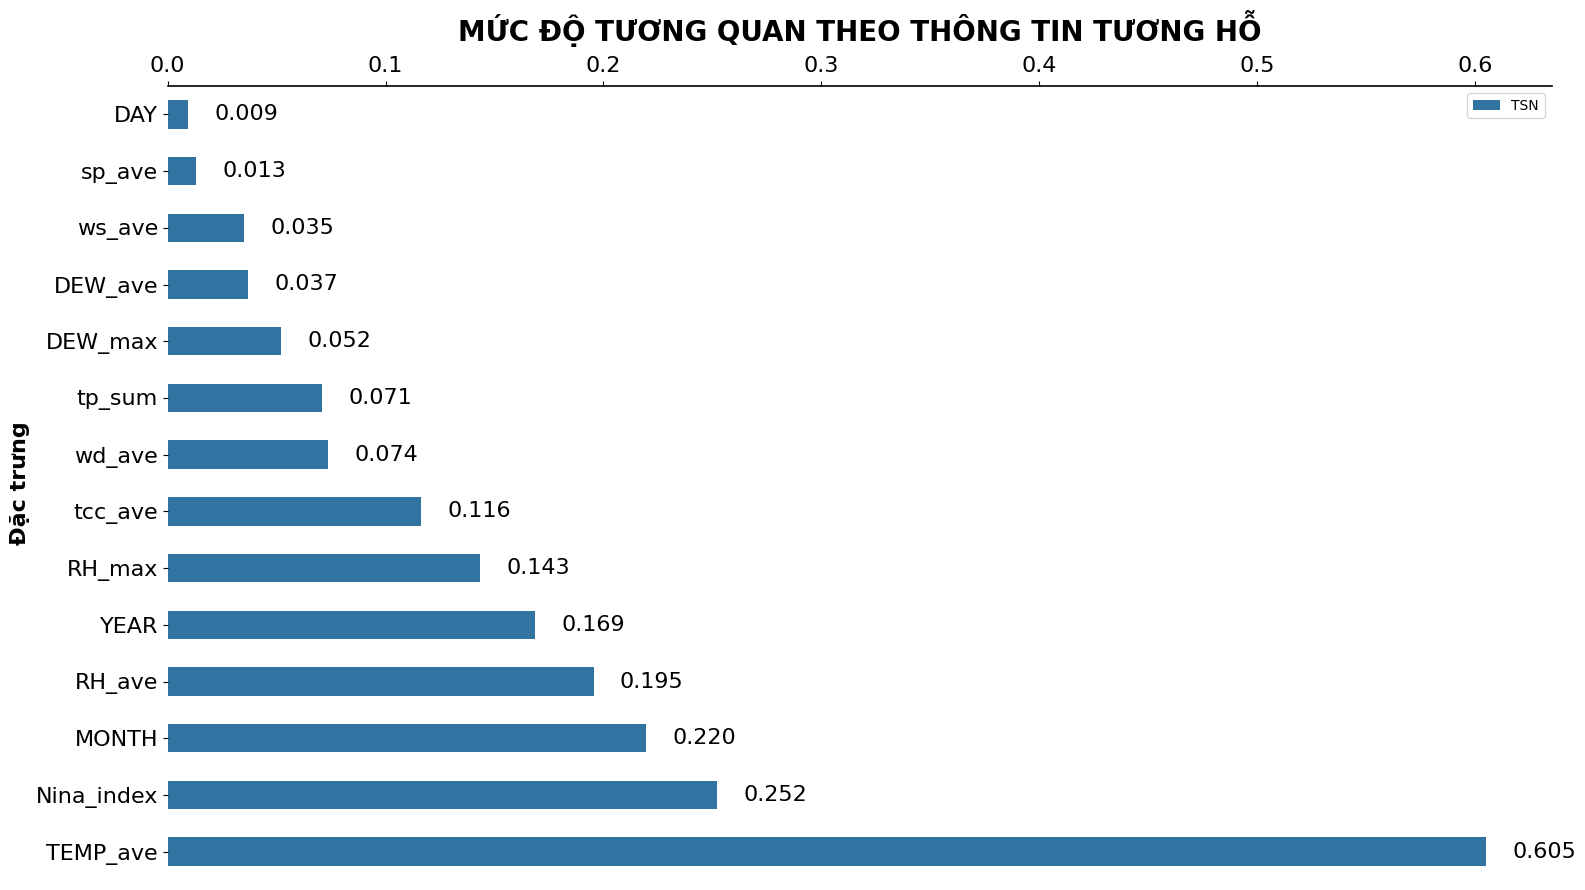

In [33]:
for name in features["NAME"].value_counts().index:
    print(f"🔸 Trạm: {name}")
    # if name != station_name:
    #     continue
    mi_scores = plots.make_mi_scores(features     = features.loc[features["NAME"] == name][feature_col], 
                                     target       = targets.loc[targets["NAME"] == name]["TEMP_max"],
                                     type         = "regression",
                                     random_state = PROJ_SEED)

    print(mi_scores)
    plots.plot_mi_scores(mi_scores,label=name)
    plt.show()

In [34]:
targets.loc[targets["NAME"] == src_name[station_name]].describe()

,TEMP_max
count,12784.000000
mean,32.761370
std,1.921343
min,20.500000
25%,32.000000
50%,33.000000
75%,34.000000
max,39.100000


In [35]:
# # # Lấy số lượng cột cần giữ lại (17 số cột có điểm MI cao nhất)
# num_columns_to_keep = 17

# # Lấy danh sách các cột cần giữ lại
# columns_to_keep = mi_scores.nlargest(num_columns_to_keep).index

# # Cập nhật X_train_encoded và X_test_encoded chỉ với các cột được giữ lại
# features = features[columns_to_keep]

# # Hiển thị các cột còn lại
# print(f"Các cột được giữ lại:\n{features.columns}")

#### <span style="color:green">4.3. Feature Engineering</span>

In [36]:
features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12784 entries, 1990-01-01 to 2024-12-31
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   NAME        12784 non-null  object 
 1   LATITUDE    12784 non-null  float64
 2   LONGITUDE   12784 non-null  float64
 3   YEAR        12784 non-null  int64  
 4   MONTH       12784 non-null  int64  
 5   DAY         12784 non-null  int64  
 6   Nina_index  12784 non-null  float64
 7   DEW_ave     12784 non-null  float64
 8   TEMP_ave    12784 non-null  float64
 9   RH_ave      12784 non-null  float64
 10  DEW_max     12784 non-null  float64
 11  RH_max      12784 non-null  float64
 12  sp_ave      12784 non-null  float64
 13  tcc_ave     12784 non-null  float64
 14  tp_sum      12784 non-null  float64
 15  ws_ave      12784 non-null  float64
 16  wd_ave      12784 non-null  float64
dtypes: float64(13), int64(3), object(1)
memory usage: 1.8+ MB


In [37]:
categorical_features = features.select_dtypes(exclude='number').columns
categorical_features

Index(['NAME'], dtype='object')

In [38]:
numerical_features = features.select_dtypes(include='number').columns
numerical_features

Index(['LATITUDE', 'LONGITUDE', 'YEAR', 'MONTH', 'DAY', 'Nina_index',
       'DEW_ave', 'TEMP_ave', 'RH_ave', 'DEW_max', 'RH_max', 'sp_ave',
       'tcc_ave', 'tp_sum', 'ws_ave', 'wd_ave'],
      dtype='object')

##### <span style="color:tomato">Encode categorical feature</span>

In [39]:
categorical_features

Index(['NAME'], dtype='object')

In [40]:
features[categorical_features]

,NAME
time,
1990-01-01,TSN
1990-01-02,TSN
1990-01-03,TSN
1990-01-04,TSN
1990-01-05,TSN
...,...
2024-12-27,TSN
2024-12-28,TSN
2024-12-29,TSN


In [41]:
# categories = [match_type[col] for col in categorical_features]
# # encoder = OrdinalEncoder(
# #     categories = categories,
# #     handle_unknown = 'use_encoded_value', 
# #     unknown_value  = -1
# # )
# encoder = OneHotEncoder(categories     = categories,
#                         sparse_output  = False,
#                         handle_unknown = "ignore")

features_encoded  = deepcopy(features)

# # # Encode
# # features_cat_encoded  = encoder.fit_transform(features[categorical_features])

# # Kiểm tra số cột
# # print("Số cột của dữ liệu đã mã hóa: ", features_cat_encoded.shape[1])

# # Loại bỏ các cột trong `categorical` khỏi features_encoded
# features_encoded  = features_encoded.drop(columns=categorical_features)

# # Thêm các cột đã mã hóa vào features_encoded
# # encoded_columns = encoder.get_feature_names_out(categorical_features)

# # Tạo DataFrame từ các cột đã mã hóa và gán lại tên cột
# # features_encoded  = pd.DataFrame(features_cat_encoded, columns=encoded_columns, index=features.index)

# # Kết hợp lại với các cột còn lại trong features_encoded
# # features_encoded  = pd.concat([features_encoded, features.drop(columns=categorical_features)], axis=1)
# features_encoded  = features

In [42]:
features_encoded

,NAME,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,Nina_index,DEW_ave,TEMP_ave,RH_ave,DEW_max,RH_max,sp_ave,tcc_ave,tp_sum,ws_ave,wd_ave
time,,,,,,,,,,,,,,,,,
1990-01-01,TSN,10.82,106.65,1990,1,1,0.01,21.18,27.03,71.46,23.0,88.51,100.97,0.499631,0.000034,1.60,150.24
1990-01-02,TSN,10.82,106.65,1990,1,2,0.01,19.52,27.14,65.54,22.0,94.67,101.02,0.704073,0.000003,2.62,116.66
1990-01-03,TSN,10.82,106.65,1990,1,3,0.01,20.49,27.19,68.43,22.0,94.06,101.11,0.231625,0.000019,1.86,110.63
1990-01-04,TSN,10.82,106.65,1990,1,4,0.01,19.71,27.22,65.14,21.0,94.06,101.14,0.250717,0.000025,1.53,110.61
1990-01-05,TSN,10.82,106.65,1990,1,5,0.01,20.37,26.94,69.37,23.0,94.06,101.22,0.730716,0.000000,1.07,289.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,TSN,10.82,106.65,2024,12,27,-0.60,24.10,26.56,87.31,26.0,100.00,101.17,0.945103,0.023795,1.21,172.07
2024-12-28,TSN,10.82,106.65,2024,12,28,-0.60,22.79,26.92,79.16,25.0,100.00,101.18,0.788628,0.010119,0.86,222.96
2024-12-29,TSN,10.82,106.65,2024,12,29,-0.60,20.21,27.00,67.58,23.0,83.55,101.13,0.672280,0.000001,1.82,90.16


#### <span style="color:green">4.4. Feature Scaling</span>

In [43]:
# features_encoded[numerical_features]
features_encoded.columns

Index(['NAME', 'LATITUDE', 'LONGITUDE', 'YEAR', 'MONTH', 'DAY', 'Nina_index',
       'DEW_ave', 'TEMP_ave', 'RH_ave', 'DEW_max', 'RH_max', 'sp_ave',
       'tcc_ave', 'tp_sum', 'ws_ave', 'wd_ave'],
      dtype='object')

In [44]:
# plots.plot_Outlier(data      = features_encoded,
#                    data_cols = feature_col,
#                    target    = "NAME")

In [45]:
features_encoded[feature_col]

,YEAR,MONTH,DAY,Nina_index,DEW_ave,TEMP_ave,RH_ave,DEW_max,RH_max,sp_ave,tcc_ave,tp_sum,ws_ave,wd_ave
time,,,,,,,,,,,,,,
1990-01-01,1990,1,1,0.01,21.18,27.03,71.46,23.0,88.51,100.97,0.499631,0.000034,1.60,150.24
1990-01-02,1990,1,2,0.01,19.52,27.14,65.54,22.0,94.67,101.02,0.704073,0.000003,2.62,116.66
1990-01-03,1990,1,3,0.01,20.49,27.19,68.43,22.0,94.06,101.11,0.231625,0.000019,1.86,110.63
1990-01-04,1990,1,4,0.01,19.71,27.22,65.14,21.0,94.06,101.14,0.250717,0.000025,1.53,110.61
1990-01-05,1990,1,5,0.01,20.37,26.94,69.37,23.0,94.06,101.22,0.730716,0.000000,1.07,289.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,2024,12,27,-0.60,24.10,26.56,87.31,26.0,100.00,101.17,0.945103,0.023795,1.21,172.07
2024-12-28,2024,12,28,-0.60,22.79,26.92,79.16,25.0,100.00,101.18,0.788628,0.010119,0.86,222.96
2024-12-29,2024,12,29,-0.60,20.21,27.00,67.58,23.0,83.55,101.13,0.672280,0.000001,1.82,90.16


##### <span style="color:tomato">Handling abnormal <~> outlier values</span>

In [46]:
# df_temp = df.copy()

In [47]:
# for name in station.keys():
#     station_temp = deepcopy(df[df['NAME'] == src_name[name]])
#     # station_temp = station_temp.drop(columns = ['NAME'],
#     #                                  axis    = 1).reset_index()
#     station_temp = station_temp.reset_index()
#     station_temp = dataset.handle_feature_outliers_over_time(data              = station_temp,
#                                                              data_cols         = numerical_features,
#                                                              station_name      = name,
#                                                              method            = "statistic",
#                                                              metrics           = list([
#                                                                                     #  "z_score",
#                                                                                     #  "z_score modified",
#                                                                                      "iqr",
#                                                                                     #  "percentile",
#                                                                                      ]),
#                                                              display           = False,
#                                                              z_thresh          = 3,    # Z_score
#                                                              modified_z_thresh = 3.5,  # Z_score modified
#                                                              k                 = 1.5,  # IQR
#                                                              p_low             = 0.01, # Percentile
#                                                              p_high            = 0.99, # Percentiled
#                                                              step_size         = 1,    # Every day
#                                                              threshold         = 0.10,
#                                                              # start_time        = "1990-01-01 00:00:00+07:00",
#                                                              # end_time          = "2025-01-01 00:00:00+07:00",
#                                                              # freq              = "1H"
#                                                              )
#     station_temp = station_temp.set_index('time')
#     df[df['NAME'] == src_name[name]] = station_temp

In [48]:
# dataset.compare_df(df_A = df_temp,
#                    df_B = df,
#                    key  = df.columns
#                    )

In [49]:
# plots.plot_Outlier(data      = df,
#                    data_cols = [col for col in feature_col if col != 'TEMP_max'],
#                    target    = "NAME")

##### <span style="color:tomato">Scaling numerical feature</span>

In [50]:
# Ép index của features_encoded và targets_encoded về dạng DatetimeIndex
features_encoded.index = pd.to_datetime(features_encoded.index)
targets_encoded.index  = pd.to_datetime(targets_encoded.index)

# Ép mốc thời gian về Timestamp (datetime)
# C1:
start_train = pd.Timestamp("1990-01-01 00:00:00")
end_train   = pd.Timestamp("2022-12-31 00:00:00")
start_test  = pd.Timestamp("2023-01-01 00:00:00")
end_test    = pd.Timestamp("2024-12-31 00:00:00")

# C2:
# idx = features_encoded.index
# split_idx = int(len(idx) * 0.8)
# start_train = idx[0]
# end_train   = idx[split_idx - 1]

# start_test  = idx[split_idx]
# end_test    = idx[-1]

# Tạo mask để lọc
train_mask = (features_encoded.index >= start_train) & (features_encoded.index <= pd.Timestamp("2020-12-31 00:00:00"))
valid_mask = (features_encoded.index >= pd.Timestamp("2021-01-01 00:00:00")) & (features_encoded.index <= end_train)
test_mask  = (features_encoded.index >= start_test) & (features_encoded.index <= end_test)

# Chia dữ liệu
X_train_encoded = features_encoded[train_mask]
X_valid_encoded = features_encoded[valid_mask]
X_test_encoded  = features_encoded[test_mask]

y_train_encoded = targets_encoded[train_mask]
y_valid_encoded = targets_encoded[valid_mask]
y_test_encoded  = targets_encoded[test_mask]

In [51]:
X_train_encoded[feature_col]

,YEAR,MONTH,DAY,Nina_index,DEW_ave,TEMP_ave,RH_ave,DEW_max,RH_max,sp_ave,tcc_ave,tp_sum,ws_ave,wd_ave
time,,,,,,,,,,,,,,
1990-01-01,1990,1,1,0.01,21.18,27.03,71.46,23.0,88.51,100.97,0.499631,0.000034,1.60,150.24
1990-01-02,1990,1,2,0.01,19.52,27.14,65.54,22.0,94.67,101.02,0.704073,0.000003,2.62,116.66
1990-01-03,1990,1,3,0.01,20.49,27.19,68.43,22.0,94.06,101.11,0.231625,0.000019,1.86,110.63
1990-01-04,1990,1,4,0.01,19.71,27.22,65.14,21.0,94.06,101.14,0.250717,0.000025,1.53,110.61
1990-01-05,1990,1,5,0.01,20.37,26.94,69.37,23.0,94.06,101.22,0.730716,0.000000,1.07,289.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-27,2020,12,27,-1.15,23.10,27.81,77.43,25.0,100.00,100.91,0.746540,0.000068,1.68,208.04
2020-12-28,2020,12,28,-1.15,22.56,27.83,74.63,24.0,94.19,100.82,0.747523,0.000137,1.39,229.65
2020-12-29,2020,12,29,-1.15,22.90,28.29,75.07,26.0,94.23,100.82,0.935189,0.000022,1.84,172.63


In [52]:
y_train_encoded

,NAME,TEMP_max
time,,
1990-01-01,TSN,32.0
1990-01-02,TSN,31.3
1990-01-03,TSN,32.3
1990-01-04,TSN,32.0
1990-01-05,TSN,31.7
...,...,...
2020-12-27,TSN,34.0
2020-12-28,TSN,33.0
2020-12-29,TSN,33.0


In [53]:
print(feature_col)
print(X_train_encoded[feature_col].shape, y_train_encoded.shape)
print(X_valid_encoded[feature_col].shape, y_valid_encoded.shape)
print(X_test_encoded[feature_col].shape, y_test_encoded.shape)

['YEAR', 'MONTH', 'DAY', 'Nina_index', 'DEW_ave', 'TEMP_ave', 'RH_ave', 'DEW_max', 'RH_max', 'sp_ave', 'tcc_ave', 'tp_sum', 'ws_ave', 'wd_ave']
(11323, 14) (11323, 2)
(730, 14) (730, 2)
(731, 14) (731, 2)


`Scale_x`

In [54]:
scaler_x = MinMaxScaler(feature_range=(-1,1))
scaler_x.fit(X_train_encoded[feature_col])

# Train
X_train_encoded_before = X_train_encoded[feature_col].copy()
X_train_encoded_after  = scaler_x.transform(X_train_encoded_before)

# Valid
X_valid_encoded_before = X_valid_encoded[feature_col].copy()
X_valid_encoded_after  = scaler_x.transform(X_valid_encoded_before)

# Test
X_test_encoded_before  = X_test_encoded[feature_col].copy()
X_test_encoded_after   = scaler_x.transform(X_test_encoded_before)

# Cast np.ndarray to pd.Dataframe
X_train_encoded_after = pd.DataFrame(data    = X_train_encoded_after, 
                                     index   = X_train_encoded.index, 
                                     columns = feature_col)
X_valid_encoded_after = pd.DataFrame(data    = X_valid_encoded_after, 
                                     index   = X_valid_encoded.index, 
                                     columns = feature_col)
X_test_encoded_after  = pd.DataFrame(data    = X_test_encoded_after,  
                                     index   = X_test_encoded.index,  
                                     columns = feature_col)

In [55]:
X_train_encoded_before.shape, X_valid_encoded_before.shape, X_test_encoded_before.shape

((11323, 14), (730, 14), (731, 14))

In [56]:
X_train_encoded_after.shape, X_valid_encoded_after.shape, X_test_encoded_after.shape

((11323, 14), (730, 14), (731, 14))

`Concat x`

In [57]:
X_train_encoded_after = pd.DataFrame(X_train_encoded_after, index=X_train_encoded.index, columns=feature_col)
X_valid_encoded_after = pd.DataFrame(X_valid_encoded_after, index=X_valid_encoded.index, columns=feature_col)
X_test_encoded_after  = pd.DataFrame(X_test_encoded_after,  index=X_test_encoded.index,  columns=feature_col)

features_encoded_after = pd.concat([X_train_encoded_after, X_valid_encoded_after, X_test_encoded_after])

features_encoded[feature_col] = features_encoded_after
features_encoded

,NAME,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,Nina_index,DEW_ave,TEMP_ave,RH_ave,DEW_max,RH_max,sp_ave,tcc_ave,tp_sum,ws_ave,wd_ave
time,,,,,,,,,,,,,,,,,
1990-01-01,TSN,10.82,106.65,-1.000000,-1.0,-1.000000,-0.207127,0.192935,0.081162,-0.100868,-0.200000,0.345113,0.203252,-0.002459,-0.999391,-0.476091,-0.183321
1990-01-02,TSN,10.82,106.65,-1.000000,-1.0,-0.933333,-0.207127,-0.032609,0.097543,-0.329219,-0.333333,0.696210,0.284553,0.407128,-0.999946,-0.051975,-0.378746
1990-01-03,TSN,10.82,106.65,-1.000000,-1.0,-0.866667,-0.207127,0.099185,0.104989,-0.217743,-0.333333,0.661442,0.430894,-0.539393,-0.999660,-0.367983,-0.413839
1990-01-04,TSN,10.82,106.65,-1.000000,-1.0,-0.800000,-0.207127,-0.006793,0.109456,-0.344648,-0.466667,0.661442,0.479675,-0.501143,-0.999552,-0.505198,-0.413956
1990-01-05,TSN,10.82,106.65,-1.000000,-1.0,-0.733333,-0.207127,0.082880,0.067759,-0.181485,-0.200000,0.661442,0.609756,0.460506,-1.000000,-0.696466,0.625735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,TSN,10.82,106.65,1.266667,1.0,0.733333,-0.478842,0.589674,0.011169,0.510511,0.200000,1.000000,0.528455,0.890017,-0.573727,-0.638254,-0.056277
2024-12-28,TSN,10.82,106.65,1.266667,1.0,0.800000,-0.478842,0.411685,0.064780,0.196143,0.066667,1.000000,0.544715,0.576529,-0.818724,-0.783784,0.239888
2024-12-29,TSN,10.82,106.65,1.266667,1.0,0.866667,-0.478842,0.061141,0.076694,-0.250530,-0.200000,0.062411,0.463415,0.343433,-0.999982,-0.384615,-0.532969


`Scale_y`

In [58]:
scaler_y = MinMaxScaler(feature_range=(-1,1))
scaler_y.fit(y_train_encoded[['TEMP_max']])

# Train
y_train_encoded_before = y_train_encoded[['TEMP_max']].copy()
y_train_encoded_after  = scaler_y.transform(y_train_encoded_before)

# Valid
y_valid_encoded_before = y_valid_encoded[['TEMP_max']].copy()
y_valid_encoded_after  = scaler_y.transform(y_valid_encoded_before)

# Test
y_test_encoded_before  = y_test_encoded[['TEMP_max']].copy()
y_test_encoded_after   = scaler_y.transform(y_test_encoded_before)

# Cast np.ndarray to pd.Dataframe
# y_train_encoded_after = pd.DataFrame(data    = y_train_encoded_after, 
#                                      index   = X_train_encoded.index, 
#                                      columns = feature_col)
# y_valid_encoded_after = pd.DataFrame(data    = y_valid_encoded_after, 
#                                      index   = X_valid_encoded.index, 
#                                      columns = feature_col)
# X_test_encoded_after  = pd.DataFrame(data    = X_test_encoded_after,  
#                                      index   = X_test_encoded.index,  
#                                      columns = feature_col)

In [59]:
targets_encoded

,NAME,TEMP_max
time,,
1990-01-01,TSN,32.0
1990-01-02,TSN,31.3
1990-01-03,TSN,32.3
1990-01-04,TSN,32.0
1990-01-05,TSN,31.7
...,...,...
2024-12-27,TSN,32.0
2024-12-28,TSN,32.0
2024-12-29,TSN,32.0


In [60]:
y_train_encoded_before.shape, y_valid_encoded_before.shape, y_test_encoded_before.shape

((11323, 1), (730, 1), (731, 1))

In [61]:
y_train_encoded_after.shape, y_valid_encoded_after.shape, y_test_encoded_after.shape

((11323, 1), (730, 1), (731, 1))

`Concat y`

In [62]:
# Chuyển tất cả thành numpy 1D
y_train_encoded_after = np.ravel(y_train_encoded_after)
y_valid_encoded_after = np.ravel(y_valid_encoded_after)
y_test_encoded_after  = np.ravel(y_test_encoded_after)

# Ghép nối theo thứ tự dòng
new_temp_max = np.concatenate([
    y_train_encoded_after,
    y_valid_encoded_after,
    y_test_encoded_after
])

# Đảm bảo độ dài khớp
assert len(new_temp_max) == len(targets_encoded), "⚠️ Số dòng không khớp!"

# Gán lại cột
targets_encoded = targets_encoded.copy()
targets_encoded["TEMP_max"] = new_temp_max

print("✅ Đã thay thế xong cột TEMP_max")

✅ Đã thay thế xong cột TEMP_max


In [63]:
targets_encoded

,NAME,TEMP_max
time,,
1990-01-01,TSN,0.236559
1990-01-02,TSN,0.161290
1990-01-03,TSN,0.268817
1990-01-04,TSN,0.236559
1990-01-05,TSN,0.204301
...,...,...
2024-12-27,TSN,0.236559
2024-12-28,TSN,0.236559
2024-12-29,TSN,0.236559


#### <span style="color:green">4.5. Save data</span>

Scaler

In [64]:
# Tạo thư mục nếu chưa tồn tại
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Lưu model
joblib.dump(value    = scaler_x, 
            filename = model_path.replace("trained_models","checkpoints") + f"scaler_x_{station_name}.pkl",
            # compress = True
            )
print(f"Scaler_x đã được lưu tại: {model_path.replace('trained_models','checkpoints')}")

Scaler_x đã được lưu tại: ../../models/checkpoints/ML/XGBOOST/


In [65]:
# Tạo thư mục nếu chưa tồn tại
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Lưu model
joblib.dump(value    = scaler_y, 
            filename = model_path.replace("trained_models","checkpoints") + f"scaler_y_{station_name}.pkl",
            # compress = True
            )
print(f"Scaler_y đã được lưu tại: {model_path.replace('trained_models','checkpoints')}")

Scaler_y đã được lưu tại: ../../models/checkpoints/ML/XGBOOST/


Data

In [66]:
# Check so dong
print(features_encoded.shape)
print(targets_encoded.shape)

(12784, 17)
(12784, 2)


In [67]:
# Reset index
# df_reset         = df.loc[features_encoded.index].reset_index()
# features_encoded = features_encoded.reset_index(drop=True)
# targets_df       = pd.DataFrame(targets_encoded, columns=["TEMP_max"]).reset_index(drop=True)

# Thay thế giá trị ở các cột trùng trong df_reset bằng features_encoded
# df_reset[features_encoded.columns] = features_encoded[features_encoded.columns]

# # Tương tự 
# df_reset[targets_df.columns] = targets_df[targets_df.columns]

df = pd.concat([features_encoded,targets_encoded["TEMP_max"]],axis=1).reset_index()

# Lưu file
os.makedirs("../../data/processed/datasets_encoded/", exist_ok=True)
file_name = f"../../data/processed/datasets_encoded/{station_name}_90.24_encoded.csv"
# file_name = f"../../data/processed/datasets_encoded/all_area_90.24_encoded.csv"
df.to_csv(file_name, index=False)
print(f"✅ Đã lưu: {file_name}")

✅ Đã lưu: ../../data/processed/datasets_encoded/TSN_90.24_encoded.csv


In [68]:
df

,time,NAME,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,Nina_index,DEW_ave,TEMP_ave,RH_ave,DEW_max,RH_max,sp_ave,tcc_ave,tp_sum,ws_ave,wd_ave,TEMP_max
0,1990-01-01,TSN,10.82,106.65,-1.000000,-1.0,-1.000000,-0.207127,0.192935,0.081162,-0.100868,-0.200000,0.345113,0.203252,-0.002459,-0.999391,-0.476091,-0.183321,0.236559
1,1990-01-02,TSN,10.82,106.65,-1.000000,-1.0,-0.933333,-0.207127,-0.032609,0.097543,-0.329219,-0.333333,0.696210,0.284553,0.407128,-0.999946,-0.051975,-0.378746,0.161290
2,1990-01-03,TSN,10.82,106.65,-1.000000,-1.0,-0.866667,-0.207127,0.099185,0.104989,-0.217743,-0.333333,0.661442,0.430894,-0.539393,-0.999660,-0.367983,-0.413839,0.268817
3,1990-01-04,TSN,10.82,106.65,-1.000000,-1.0,-0.800000,-0.207127,-0.006793,0.109456,-0.344648,-0.466667,0.661442,0.479675,-0.501143,-0.999552,-0.505198,-0.413956,0.236559
4,1990-01-05,TSN,10.82,106.65,-1.000000,-1.0,-0.733333,-0.207127,0.082880,0.067759,-0.181485,-0.200000,0.661442,0.609756,0.460506,-1.000000,-0.696466,0.625735,0.204301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12779,2024-12-27,TSN,10.82,106.65,1.266667,1.0,0.733333,-0.478842,0.589674,0.011169,0.510511,0.200000,1.000000,0.528455,0.890017,-0.573727,-0.638254,-0.056277,0.236559
12780,2024-12-28,TSN,10.82,106.65,1.266667,1.0,0.800000,-0.478842,0.411685,0.064780,0.196143,0.066667,1.000000,0.544715,0.576529,-0.818724,-0.783784,0.239888,0.236559
12781,2024-12-29,TSN,10.82,106.65,1.266667,1.0,0.866667,-0.478842,0.061141,0.076694,-0.250530,-0.200000,0.062411,0.463415,0.343433,-0.999982,-0.384615,-0.532969,0.236559
12782,2024-12-30,TSN,10.82,106.65,1.266667,1.0,0.933333,-0.478842,0.309783,0.142219,-0.022179,-0.066667,0.668852,0.430894,0.087714,-0.999839,-0.588358,0.440784,0.236559


### <span style="color:orange">5.Model</span>

#### <span style="color:green">5.1. Loading the dataset</span>

In [69]:
src_encoded = dict({"CaMau" : "../../data/processed/datasets_encoded/CaMau_90.24_encoded.csv",
                    "DH"    : "../../data/processed/datasets_encoded/DH_90.24_encoded.csv",
                    "NB"    : "../../data/processed/datasets_encoded/NB_90.24_encoded.csv",
                    "QN"    : "../../data/processed/datasets_encoded/QN_90.24_encoded.csv",
                    "TH"    : "../../data/processed/datasets_encoded/TH_90.24_encoded.csv",
                    "TSN"   : "../../data/processed/datasets_encoded/TSN_90.24_encoded.csv"})
# src_encoded = dict({"all" : "../../data/processed/datasets_encoded/all_area_90.24_encoded.csv"})

In [70]:
df               = pd.read_csv(filepath_or_buffer = src_encoded[station_name],
                               parse_dates        = True,
                            #    nrows              = nrows,
                               index_col          = "time")
targets_encoded  = df[['NAME',"TEMP_max"]]
features_encoded = df.drop(columns = ["TEMP_max"])

In [71]:
features_encoded[feature_col]

,YEAR,MONTH,DAY,Nina_index,DEW_ave,TEMP_ave,RH_ave,DEW_max,RH_max,sp_ave,tcc_ave,tp_sum,ws_ave,wd_ave
time,,,,,,,,,,,,,,
1990-01-01,-1.000000,-1.0,-1.000000,-0.207127,0.192935,0.081162,-0.100868,-0.200000,0.345113,0.203252,-0.002459,-0.999391,-0.476091,-0.183321
1990-01-02,-1.000000,-1.0,-0.933333,-0.207127,-0.032609,0.097543,-0.329219,-0.333333,0.696210,0.284553,0.407128,-0.999946,-0.051975,-0.378746
1990-01-03,-1.000000,-1.0,-0.866667,-0.207127,0.099185,0.104989,-0.217743,-0.333333,0.661442,0.430894,-0.539393,-0.999660,-0.367983,-0.413839
1990-01-04,-1.000000,-1.0,-0.800000,-0.207127,-0.006793,0.109456,-0.344648,-0.466667,0.661442,0.479675,-0.501143,-0.999552,-0.505198,-0.413956
1990-01-05,-1.000000,-1.0,-0.733333,-0.207127,0.082880,0.067759,-0.181485,-0.200000,0.661442,0.609756,0.460506,-1.000000,-0.696466,0.625735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,1.266667,1.0,0.733333,-0.478842,0.589674,0.011169,0.510511,0.200000,1.000000,0.528455,0.890017,-0.573727,-0.638254,-0.056277
2024-12-28,1.266667,1.0,0.800000,-0.478842,0.411685,0.064780,0.196143,0.066667,1.000000,0.544715,0.576529,-0.818724,-0.783784,0.239888
2024-12-29,1.266667,1.0,0.866667,-0.478842,0.061141,0.076694,-0.250530,-0.200000,0.062411,0.463415,0.343433,-0.999982,-0.384615,-0.532969


In [72]:
targets_encoded

,NAME,TEMP_max
time,,
1990-01-01,TSN,0.236559
1990-01-02,TSN,0.161290
1990-01-03,TSN,0.268817
1990-01-04,TSN,0.236559
1990-01-05,TSN,0.204301
...,...,...
2024-12-27,TSN,0.236559
2024-12-28,TSN,0.236559
2024-12-29,TSN,0.236559


#### <span style="color:green">5.2. Splitting the dataset</span>

`Spliting`

In [73]:
# Ép index của features_encoded và targets_encoded về dạng DatetimeIndex
features_encoded.index = pd.to_datetime(features_encoded.index)
targets_encoded.index  = pd.to_datetime(targets_encoded.index)

# Ép mốc thời gian về Timestamp (datetime)
# C1:
start_train = pd.Timestamp("1990-01-01 00:00:00")
end_train   = pd.Timestamp("2022-12-31 00:00:00")
start_test  = pd.Timestamp("2023-01-01 00:00:00")
end_test    = pd.Timestamp("2024-12-31 00:00:00")

# C2:
# idx = features_encoded.index
# split_idx = int(len(idx) * 0.8)
# start_train = idx[0]
# end_train   = idx[split_idx - 1]

# start_test  = idx[split_idx]
# end_test    = idx[-1]

# Tạo mask để lọc
train_mask = (features_encoded.index >= start_train) & (features_encoded.index <= pd.Timestamp("2020-12-31 00:00:00"))
valid_mask = (features_encoded.index >= pd.Timestamp("2021-01-01 00:00:00")) & (features_encoded.index <= end_train)
test_mask  = (features_encoded.index >= start_test) & (features_encoded.index <= end_test)

# Chia dữ liệu
X_train_encoded = features_encoded[train_mask]
X_valid_encoded = features_encoded[valid_mask]
X_test_encoded  = features_encoded[test_mask]

y_train_encoded = targets_encoded[train_mask]
y_valid_encoded = targets_encoded[valid_mask]
y_test_encoded  = targets_encoded[test_mask]

In [74]:
X_train_encoded[feature_col]

,YEAR,MONTH,DAY,Nina_index,DEW_ave,TEMP_ave,RH_ave,DEW_max,RH_max,sp_ave,tcc_ave,tp_sum,ws_ave,wd_ave
time,,,,,,,,,,,,,,
1990-01-01,-1.0,-1.0,-1.000000,-0.207127,0.192935,0.081162,-0.100868,-0.200000,0.345113,0.203252,-0.002459,-0.999391,-0.476091,-0.183321
1990-01-02,-1.0,-1.0,-0.933333,-0.207127,-0.032609,0.097543,-0.329219,-0.333333,0.696210,0.284553,0.407128,-0.999946,-0.051975,-0.378746
1990-01-03,-1.0,-1.0,-0.866667,-0.207127,0.099185,0.104989,-0.217743,-0.333333,0.661442,0.430894,-0.539393,-0.999660,-0.367983,-0.413839
1990-01-04,-1.0,-1.0,-0.800000,-0.207127,-0.006793,0.109456,-0.344648,-0.466667,0.661442,0.479675,-0.501143,-0.999552,-0.505198,-0.413956
1990-01-05,-1.0,-1.0,-0.733333,-0.207127,0.082880,0.067759,-0.181485,-0.200000,0.661442,0.609756,0.460506,-1.000000,-0.696466,0.625735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-27,1.0,1.0,0.733333,-0.723831,0.453804,0.197319,0.129412,0.066667,1.000000,0.105691,0.492208,-0.998782,-0.442827,0.153058
2020-12-28,1.0,1.0,0.800000,-0.723831,0.380435,0.200298,0.021408,-0.066667,0.668852,-0.040650,0.494178,-0.997546,-0.563410,0.278822
2020-12-29,1.0,1.0,0.866667,-0.723831,0.426630,0.268801,0.038380,0.200000,0.671131,-0.040650,0.870155,-0.999606,-0.376299,-0.053018


In [75]:
y_train_encoded

,NAME,TEMP_max
time,,
1990-01-01,TSN,0.236559
1990-01-02,TSN,0.161290
1990-01-03,TSN,0.268817
1990-01-04,TSN,0.236559
1990-01-05,TSN,0.204301
...,...,...
2020-12-27,TSN,0.451613
2020-12-28,TSN,0.344086
2020-12-29,TSN,0.344086


In [76]:
print(feature_col)
print(X_train_encoded[feature_col].shape, y_train_encoded.shape)
print(X_valid_encoded[feature_col].shape, y_valid_encoded.shape)
print(X_test_encoded[feature_col].shape, y_test_encoded.shape)

['YEAR', 'MONTH', 'DAY', 'Nina_index', 'DEW_ave', 'TEMP_ave', 'RH_ave', 'DEW_max', 'RH_max', 'sp_ave', 'tcc_ave', 'tp_sum', 'ws_ave', 'wd_ave']
(11323, 14) (11323, 2)
(730, 14) (730, 2)
(731, 14) (731, 2)


`Merging data into (TFT dataset) format`

In [77]:
# # Gộp các tập train/valid/test
# train_df = X_train_encoded[feature_col].copy()
# train_df["TEMP_max"] = y_train_encoded["TEMP_max"]

# valid_df = X_valid_encoded[feature_col].copy()
# valid_df["TEMP_max"] = y_valid_encoded["TEMP_max"]

# test_df = X_test_encoded[feature_col].copy()
# test_df["TEMP_max"] = y_test_encoded["TEMP_max"]

# # Nối lại
# df_all = pd.concat([train_df, valid_df, test_df], ignore_index=False)

# # Giả sử datetime index đã có sẵn
# # Nếu chưa có index, bạn có thể tạo từ YEAR, MONTH, DAY:
# # df_all.index = pd.to_datetime(df_all[["YEAR","MONTH","DAY"]])

# # Tạo time_idx = số ngày kể từ ngày đầu
# df_all["time_idx"] = (df_all.index - df_all.index.min()).days

# # Thêm station_id
# df_all["station_id"] = station_name
# df_all["station_id"] = df_all["station_id"].astype(str)

# # Chia train/valid/test theo datetime index
# train_cutoff = df_all.index < pd.Timestamp("2021-01-01")
# valid_cutoff = (df_all.index >= pd.Timestamp("2021-01-01")) & (df_all.index < pd.Timestamp("2023-01-01"))
# test_cutoff  = df_all.index >= pd.Timestamp("2023-01-01")


In [78]:
# df_all

In [79]:
# max_encoder_length = 30  # 2 năm nhìn lại
# max_prediction_length = 1  # dự báo 30 ngày

# training = TimeSeriesDataSet(
#     df_all[train_cutoff],
#     time_idx                   = "time_idx",
#     target                     = "TEMP_max",
#     group_ids                  = ["station_id"],
#     min_encoder_length         = max_encoder_length//2,
#     max_encoder_length         = max_encoder_length,
#     min_prediction_length      = 1,
#     max_prediction_length      = max_prediction_length,
#     time_varying_known_reals   = ["YEAR","MONTH","DAY","Nina_index"],
#     time_varying_unknown_reals = [
#         "DEW_ave","TEMP_ave","RH_ave","DEW_max",
#         "RH_max","sp_ave","tcc_ave","tp_sum",
#         "ws_ave","wd_ave","TEMP_max"
#     ],
#     target_normalizer     = None,   # không normalize nữa vì dữ liệu đã scale
#     add_relative_time_idx = True,
#     add_target_scales     = True,
#     add_encoder_length    = True
# )


# validation = TimeSeriesDataSet.from_dataset(training, df_all[valid_cutoff])
# test_dataset = TimeSeriesDataSet.from_dataset(training, df_all[test_cutoff], predict=True, stop_randomization=True)


In [80]:
# batch_size = 64
# train_dataloader = DataLoader(training, batch_size=batch_size, shuffle=True)
# val_dataloader   = DataLoader(validation, batch_size=batch_size, shuffle=False)
# test_dataloader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#### <span style="color:green">5.3. Building models</span>

<a href="https://link.springer.com/article/10.1023/A:1010933404324">Random Forest</a>

<a href="https://youtu.be/v6VJ2RO66Ag?si=PjRmGGXido5Pj9Bd">Random Forest Algorithm Clearly Explained!</a>

<a href="https://youtu.be/_QuGM_FW9eo?si=euE6Tpslgb0Vbg_F">Random Forest Algorithm Explained with Python and scikit-learn</a>

<a href="https://youtu.be/PAXpE-h4X2g?si=oR2skNoU8cqtcJeu">Xác định thuộc tính quan trọng bằng Random Forest</a>

##### <span style="color:tomato">Building Models ~ aproach1</span>

`Wrapper`

In [81]:
class ModelWrapper:
    def __init__(self,
                 model_name             = "TFT",
                 learning_rate          = 0.03,
                 hidden_size            = 16,
                 attention_head_size    = 1,
                 dropout                = 0.1,
                 hidden_continuous_size = 8,
                 output_size            = 1,
                 loss                   = None,
                 **kwargs):
        self.model_name             = model_name
        self.learning_rate          = learning_rate
        self.hidden_size            = hidden_size
        self.attention_head_size    = attention_head_size
        self.dropout                = dropout
        self.hidden_continuous_size = hidden_continuous_size
        self.output_size            = output_size
        self.loss                   = loss or QuantileLoss()
        self.kwargs                 = kwargs

        self.model   = None
        self.dataset = None

    # -----------------------
    # Dataset setup
    # -----------------------
    def _create_dataset(self, X, y):
        # ✅ Ép tất cả về float trước
        X = X.astype(float)
        y = y.astype(float) if isinstance(y, pd.DataFrame) or isinstance(y, pd.Series) else np.array(y, dtype=float)    

        df = pd.DataFrame(X).copy()
        df["target"]   = y.values if isinstance(y, pd.Series) else y
        df["time_idx"] = range(len(df))
        df["group_id"] = 0  

        self.dataset = TimeSeriesDataSet(
            df,
            time_idx                   = "time_idx",
            target                     = "target",
            group_ids                  = ["group_id"],
            max_encoder_length         = 24,
            max_prediction_length      = 1,
            time_varying_known_reals   = list(X.columns),
            time_varying_unknown_reals = ["target"],
        )   

        return self.dataset

    # -----------------------
    # Fit model
    # -----------------------
    def fit(self, X, y, batch_size=64, max_epochs=10, accelerator="gpu", devices=1):
        dataset = self._create_dataset(X, y)
        dataloader = dataset.to_dataloader(train=True, batch_size=batch_size, shuffle=True)

        # ✅ Khởi tạo model TFT gốc
        tft_model = TemporalFusionTransformer.from_dataset(
            dataset,
            learning_rate          = self.learning_rate,
            hidden_size            = self.hidden_size,
            attention_head_size    = self.attention_head_size,
            dropout                = self.dropout,
            hidden_continuous_size = self.hidden_continuous_size,
            output_size            = self.output_size,
            loss                   = self.loss,
            **self.kwargs
        )

        # ✅ Bọc lại TFT bằng LightningModule để Trainer hiểu
        class _TFTLightningModule(pl.LightningModule):
            def __init__(self, tft_model):
                super().__init__()
                self.model   = tft_model
                self.loss_fn = nn.MSELoss()  # hoặc QuantileLoss nếu muốn

            def training_step(self, batch, batch_idx):
                x, y = batch
                y = y[0]  # lấy đúng tensor
                y_pred = self.model(x)
                if isinstance(y_pred, tuple):
                    y_pred = y_pred[0]
                y_pred = y_pred.squeeze(-1)
                y = y.squeeze(-1)
                loss = self.loss_fn(y_pred, y)
                self.log("train_loss", loss)
                return loss

            def configure_optimizers(self):
                return torch.optim.Adam(self.parameters(), lr=1e-3)


        lightning_model = _TFTLightningModule(tft_model)

        trainer = Trainer(max_epochs=max_epochs, accelerator=accelerator, devices=devices)
        trainer.fit(lightning_model, train_dataloaders=dataloader)

        # ✅ Lưu lại model gốc (tft_model)
        self.model = tft_model
        return self

    # -----------------------
    # Predict
    # -----------------------
    def predict(self, X):
        if self.model is None or self.dataset is None:
            raise ValueError("Model chưa được huấn luyện, hãy gọi fit() trước.")

        # ✅ Ép tất cả về float trước
        X = X.astype(float)

        df = pd.DataFrame(X).copy()
        df["target"] = 0.0
        df["time_idx"] = range(len(df))
        df["group_id"] = 0

        dataset = TimeSeriesDataSet.from_dataset(self.dataset, df, predict=True, stop_randomization=True)
        loader = dataset.to_dataloader(train=False, batch_size=64)
        preds = self.model.predict(loader, mode="prediction").numpy()
        return preds

    # -----------------------
    # Get/Set params
    # -----------------------
    def get_params(self, deep=True):
        return {
            "model_name": self.model_name,
            "learning_rate": self.learning_rate,
            "hidden_size": self.hidden_size,
            "attention_head_size": self.attention_head_size,
            "dropout": self.dropout,
            "hidden_continuous_size": self.hidden_continuous_size,
            "output_size": self.output_size,
            "loss": self.loss,
            **self.kwargs
        }

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        return self

`Continue`

In [82]:
reg_model = ModelWrapper("TFT",
                         learning_rate=0.001,
                         hidden_size=16,
                         attention_head_size=4,
                         dropout=0.1,
                         hidden_continuous_size=8,
                         output_size=1)

In [83]:
reg_model.get_params()["learning_rate"]

0.001

In [84]:
torch.cuda.is_available()

False

In [ ]:
reg_model.fit(X_train_encoded[feature_col],y_train_encoded["TEMP_max"])

In [ ]:
X_train_encoded[feature_col]

In [ ]:
y = reg_model.predict(X_train_encoded[feature_col])
y

##### <span style="color:tomato">Building Models ~ aproach2</span>

🧠 So sánh: GridSearchCV vs RandomizedSearchCV
| Tiêu chí                             | `GridSearchCV`                                             | `RandomizedSearchCV`                                                             |
| ------------------------------------ | ---------------------------------------------------------- | -------------------------------------------------------------------------------- |
| **Chiến lược tìm kiếm**              | Tìm kiếm toàn bộ tổ hợp các giá trị trong `param_grid`.    | Lấy mẫu ngẫu nhiên từ không gian siêu tham số với số tổ hợp cố định.             |
| **Hiệu quả tính toán**               | Rất tốn thời gian nếu có nhiều tham số hoặc nhiều giá trị. | Nhanh hơn nhiều vì chỉ thử một số tổ hợp nhất định.                              |
| **Khả năng bao phủ toàn diện**       | Bao phủ toàn bộ không gian tham số được chỉ định.          | Không bao phủ toàn bộ không gian, nhưng có thể khám phá rộng hơn nếu set hợp lý. |
| **Số lượng tổ hợp cần thử**          | Bằng tích số giá trị của từng tham số.                     | Do người dùng chỉ định (qua `n_iter`).                                           |
| **Thích hợp cho bài toán nào?**      | Khi không gian tìm kiếm nhỏ và muốn tối ưu tuyệt đối.      | Khi không gian tìm kiếm lớn hoặc cần tiết kiệm thời gian.                        |
| **Xử lý tham số liên tục**           | Cần chỉ định danh sách cụ thể (discrete).                  | Có thể chỉ định phân phối liên tục (vd: `uniform`, `loguniform`).                |
| **Hỗ trợ phân phối tham số**         | ❌ Không hỗ trợ (chỉ duyệt danh sách cụ thể).               | ✅ Hỗ trợ (qua `scipy.stats`, ví dụ `randint`, `uniform`, v.v.).                  |
| **Tái lập kết quả (`random_state`)** | Không cần, vì duyệt toàn bộ.                               | Cần thiết nếu muốn tái lập kết quả thử nghiệm.                                   |


✅ Tóm lại:

Dùng GridSearchCV nếu:

- Bạn biết rõ phạm vi tham số nhỏ và muốn tìm tổ hợp tốt nhất tuyệt đối.
- Bạn có tài nguyên tính toán dồi dào và thời gian chạy không phải vấn đề.

Dùng RandomizedSearchCV nếu:

- Bạn muốn đánh đổi giữa tốc độ và chất lượng giải pháp.
- Bạn có nhiều tham số hoặc phạm vi quá lớn.
- Bạn muốn thử nghiệm sơ bộ để rút gọn phạm vi tìm kiếm cho GridSearchCV.

In [ ]:
# param_grid = {
#     'n_estimators'             : [100, 200, 300, 500],  # Number of trees in the forest
#     'max_depth'                : [5, 10, 20, 30, 50],   # Maximum depth of the tree
#     'min_samples_split'        : [2, 5, 10],            # Minimum number of samples required to split an internal node
#     'min_samples_leaf'         : [1, 2, 4],             # Minimum number of samples required to be at a leaf node
#     'min_impurity_decrease'    : [0.0, 0.01, 0.02],     # A node will be split if this split induces a decrease in impurity greater than or equal to this value
#     'max_features'             : [0.5, 0.75, 1.0],      # Fraction of features to consider when looking for the best split
#     'ccp_alpha'                : [0.0, 0.001, 0.01],    # Complexity parameter used for Minimal Cost-Complexity Pruning
#     'min_weight_fraction_leaf' : [0.0, 0.01, 0.02],     # Minimum weighted fraction of the input samples required to be at a leaf node
# }

# reg_model = train_model.FindBestTuningModel(model       = reg_model,
#                                             method      = "GridSearchCV",
#                                             scoring     = {
#                                                            'r2'   : 'r2',    
#                                                         #    'mae'  : 'neg_mean_absolute_error',
#                                                         #    'mse'  : 'neg_mean_squared_error',
#                                                         #    'msle' : 'neg_mean_squared_log_error',
#                                                         #    'mape' : 'neg_mean_absolute_percentage_error'
#                                                            },
#                                             refit       = "r2",
#                                             n_jobs      = 2,
#                                             param_grid  = param_grid,
#                                             train_X     = features_encoded[features.columns].iloc[:10],
#                                             train_y     = targets_encoded.iloc[:10])

##### <span style="color:tomato">Building Models ~ aproach3</span>

Việc tuning lần lượt từng tham số (params) là cách tiếp cận theo kiểu manual sequential tuning – vừa tiết kiệm tài nguyên, vừa dễ kiểm soát. Tuy nhiên, thứ tự tuning các tham số rất quan trọng, vì một số tham số ảnh hưởng mạnh hơn những cái còn lại.

✅ Thứ tự khuyến nghị khi tuning RandomForestRegressor:
- Mục tiêu: Ưu tiên tuning các tham số có ảnh hưởng lớn nhất đến mô hình và giảm thời gian huấn luyện trước.

🔢 Thứ tự tuning hợp lý:
| Thứ tự | Tham số                    | Ý nghĩa ngắn gọn                                                               |
| ------ | -------------------------- | ------------------------------------------------------------------------------ |
| 1️⃣    | `n_estimators`             | Số lượng cây (ảnh hưởng lớn đến độ chính xác và độ ổn định)                    |
| 2️⃣    | `max_depth`                | Độ sâu cây (kiểm soát overfitting / underfitting)                              |
| 3️⃣    | `min_samples_split`        | Số lượng mẫu tối thiểu để tách một node (ảnh hưởng đến phân nhánh sớm/muộn)    |
| 4️⃣    | `min_samples_leaf`         | Số lượng mẫu tối thiểu tại một lá (giúp làm mượt dự đoán)                      |
| 5️⃣    | `max_features`             | Tỷ lệ feature được xét ở mỗi split (ảnh hưởng đến ngẫu nhiên và bias-variance) |
| 6️⃣    | `min_impurity_decrease`    | Ngưỡng impurity giảm tối thiểu để chia node                                    |
| 7️⃣    | `min_weight_fraction_leaf` | Tỷ lệ mẫu tối thiểu tại một lá (thường ít dùng)                                |
| 8️⃣    | `ccp_alpha`                | Pruning (chỉ áp dụng nếu bạn muốn cắt tỉa cây để đơn giản mô hình)             |


📌 Gợi ý flow tuning:
1. Chọn base model (RandomForestRegressor hoặc XGBRegressor)
2. Fix random_state, chọn train/test cố định.
3. Tuning theo thứ tự:
+ a. n_estimators
+ b. max_depth
+ c. min_samples_split
+ d. min_samples_leaf
+ e. max_features
+ f. min_impurity_decrease
+ h. min_weight_fraction_leaf (nếu cần)
+ g. ccp_alpha
4. Đánh giá R2 hoặc MAE để chọn param tốt nhất từng bước.


In [ ]:
param_grid_default = {
    'n_estimators'      : [reg_model.get_params()['n_estimators']],
    'max_depth'         : [reg_model.get_params()['max_depth']],
    'learning_rate'     : [reg_model.get_params()['learning_rate']],
    'min_child_weight'  : [reg_model.get_params()['min_child_weight']],
    'gamma'             : [reg_model.get_params()['gamma']],
    'subsample'         : [reg_model.get_params()['subsample']],
    'colsample_bytree'  : [reg_model.get_params()['colsample_bytree']],
    'colsample_bylevel' : [reg_model.get_params()['colsample_bylevel']],
    'colsample_bynode'  : [reg_model.get_params()['colsample_bynode']],
    'reg_lambda'        : [reg_model.get_params()['reg_lambda']],
    'reg_alpha'         : [reg_model.get_params()['reg_alpha']],
    'scale_pos_weight'  : [reg_model.get_params()['scale_pos_weight']],
}
param_grid_default

In [ ]:
step = 15 # ~ +60 n_estimators each loop
pad_size = 0.01
param_grid = {
    'n_estimators'      : param_grid_default["n_estimators"] + np.linspace(100, 1000, step, dtype=int).tolist(),
    'max_depth'         : param_grid_default["max_depth"] + np.linspace(3, 15, step, dtype=int).tolist(),
    'learning_rate'     : param_grid_default["learning_rate"] + np.round(np.linspace(0.01, 0.3, step, dtype=float), 2).tolist(),
    'min_child_weight'  : param_grid_default["min_child_weight"] + np.linspace(0, 10, step, dtype=int).tolist(),
    'gamma'             : param_grid_default['gamma'] + np.round(np.linspace(0, 5, step, dtype=float), 2).tolist(),
    'subsample'         : param_grid_default["subsample"] + np.round(np.linspace(0.0 + pad_size, 
                                                                                 1.0, step), 2).tolist(), 
    'colsample_bytree'  : param_grid_default["colsample_bytree"] + np.round(np.linspace(0.0 + pad_size, 
                                                                                        1.0, step), 2).tolist(), 
    'colsample_bylevel' : param_grid_default["colsample_bylevel"] + np.round(np.linspace(0.0 + pad_size, 
                                                                                         1.0, step), 2).tolist(), 
    'colsample_bynode'  : param_grid_default["colsample_bynode"] + np.round(np.linspace(0.0 + pad_size, 
                                                                                        1.0, step), 2).tolist(), 
    'reg_lambda'        : param_grid_default["reg_lambda"] + np.round(np.linspace(0.0, 10, step), 2).tolist(), 
    'reg_alpha'         : param_grid_default["reg_alpha"] + np.round(np.linspace(0.0, 10, step), 2).tolist(), 
    'scale_pos_weight'  : param_grid_default["scale_pos_weight"] + np.round(np.linspace(1, 100, step), 2).tolist(), 
}
param_grid

In [ ]:
best_score = plots.plot_evaluate_params_over_time(
                                                  # data             = df[feature_col].join(targets_encoded["TEMP_max"]).reset_index(), 
                                                  target_cols_name = "TEMP_max", 
                                                  station_name     = station_name, 
                                                  x_fit            = list([X_train_encoded[feature_col], 
                                                                           X_valid_encoded[feature_col]]),
                                                  y_true           = list([y_train_encoded["TEMP_max"], 
                                                                           y_valid_encoded["TEMP_max"]]),
                                                  model            = reg_model,
                                                  params           = param_grid,
                                                  method           = "short",
                                                  metrics          = list([
                                                                          # # only this one
                                                                        #    "R2", # NOT USE!!!  
                                                                           
                                                                          # # or single [all] of the rest
                                                                           "MAE",
                                                                           "MSE",
                                                                          #  "RMSE"
                                                                           "MSLE",
                                                                           "MAPE"
                                                                           ]),
                                                  wrapper          = ModelWrapper,
                                                  scaler           = scaler_y,
                                                  display          = True,
                                                  step_size        = 365, # FASTER <~> DOESNT AFFECT OUTPUT BUT SPEED
                                                  # record           = 0.890157940645714,
                                                 #  start_time       = "1990-01-01 00:00:00+07:00",
                                                 #  end_time         = "2023-01-01 00:00:00+07:00",
                                                  # freq             = "1H"
                                                  )

CaMau

In [ ]:
# param_grid['reg_alpha']  = [5.0]
# param_grid['reg_lambda'] = [5.71]

DH

In [ ]:
# param_grid['learning_rate']    = [0.09]
# param_grid['min_child_weight'] = [6]
# param_grid['n_estimators']     = [228]
# param_grid['scale_pos_weight'] = [71.71]

NB

In [ ]:
# param_grid['learning_rate']    = [0.2]
# param_grid['scale_pos_weight'] = [71.71]

QN

In [ ]:
# param_grid['learning_rate']    = [0.13]
# param_grid['min_child_weight'] = [4]
# param_grid['colsample_bynode'] = [0.79]
# param_grid['reg_lambda']       = [0.0]

TH

In [ ]:
# param_grid['learning_rate']     = [0.07]
# param_grid['colsample_bylevel'] = [0.58]
# param_grid['max_depth']         = [7]
# param_grid['min_child_weight']  = [10]

TSN

In [ ]:
# param_grid['learning_rate']    = [0.16]
# param_grid['reg_lambda']       = [7.86]
# param_grid['scale_pos_weight'] = [85.86]
# param_grid['min_child_weight'] = [3]
# param_grid['n_estimators']     = [164]

SET UP PARAMS

In [ ]:
param_grid

In [ ]:
reg_model.set_params(**dict({k : v[0] for k,v in param_grid.items()}))
reg_model

Save model

In [ ]:
# Tạo thư mục nếu chưa tồn tại
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Lưu model
joblib.dump(value    = reg_model, 
            filename = model_path + f"XGB_based_{station_name}.pkl",
            # compress = True
            )
print(f"Model đã được lưu tại: {model_path}")

##### <span style="color:tomato">Building Models ~ aproach4</span>

In [ ]:
# # Load lại model
reg_model = joblib.load(model_path + f"XGB_based_{station_name}.pkl")

#### <span style="color:green">5.4. Training models</span>

##### <span style="color:tomato">Training Models ~ aproach1</span>

Only used when model's performance was too BAD!!!

In [ ]:
# reg_model.set_params(warm_start = True)

# df_train = pd.concat([X_train_encoded[feature_col], y_train_encoded],axis=1)
# df_train

In [ ]:
# n_splits = 5
# tss      = TimeSeriesSplit(n_splits)

visualize

In [ ]:
# fig, axes = plt.subplots(n_splits, 1, 
#                          figsize = (15,15),
#                          sharex = True)

# fold = 0
# for train_idx, val_idx in tss.split(df_train):
#     train = df.iloc[train_idx]
#     test  = df.iloc[val_idx]
    
    
#     FEATURES = feature_col
#     TARGET   = targets.name
    
#     train[TARGET].plot(ax    = axes[fold],
#                        label = "Training Set",
#                        title = f"Data Train/Test Split Fold {fold}")
#     test[TARGET].plot(ax    = axes[fold],
#                       label = "Test Set")
#     axes[fold].axvline(test.index.min(),
#                 color = "black",
#                 ls    = "--")
#     fold += 1

training

In [ ]:
# fold   = 0
# preds  = []
# scores = []
# for train_idx, val_idx in tss.split(df_train):
#     train = df.iloc[train_idx]
#     test  = df.iloc[val_idx]
    
#     FEATURES = feature_col
#     TARGET   = targets.name
    
#     X_train = train[FEATURES]
#     y_train = train[TARGET]
    
#     X_test = test[FEATURES]
#     y_test = test[TARGET]
    
#     reg_model.fit(X_train, y_train)
    
#     print()
    
#     y_pred = reg_model.predict(X_test)
#     preds.append(y_pred)
#     score = np.sqrt(mean_squared_error(y_true = y_test,
#                                        y_pred = y_pred))
#     scores.append(score)

In [ ]:
# print(f"Score across folds {np.mean(scores):0.4f}")
# print(f"Fold scores:{scores}")

In [ ]:
# reg_model.set_params(warm_start = False)

##### <span style="color:tomato">Training Models ~ aproach2</span>

In [ ]:
reg_model.set_params(**dict({k : v[0] for k,v in param_grid.items()}))

In [ ]:
reg_model.set_params(callbacks   = [early_stopping],
                     eval_metric = [
                                    # "rmse",
                                    "mae",
                                    # "rmsle",
                                    "mape"])

In [ ]:
reg_model.fit(X        = X_train_encoded[feature_col],
              y        = y_train_encoded["TEMP_max"],
              eval_set = [(X_valid_encoded[feature_col], y_valid_encoded["TEMP_max"])],
              verbose  = 1)

In [ ]:
dict(reg_model.hparams)

In [ ]:
# reg_model.set_params(warm_start = False)

In [ ]:
# # SLOWWWWWW
# fn = X_train_encoded[feature_col].columns
# cn = [y_train_encoded.name]
# # fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
# plot_tree(reg_model.estimators_[0],
#           feature_names = fn, 
#           class_names   = cn,
#           filled        = True)
# plt.title("Decision Tree from the Random Forest")
# plt.show()

##### <span style="color:tomato">Training Models ~ aproach3</span>

#### <span style="color:green">5.5. Save models</span>

In [ ]:
# Tạo thư mục nếu chưa tồn tại
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Lưu model
joblib.dump(value    = reg_model, 
            filename = model_path + f"XGB_trained_{station_name}.pkl",
            # compress = True
            )
print(f"Model đã được lưu tại: {model_path}")

### <span style="color:orange">6.Model Evaluation</span>

In [ ]:
# # Load lại model
reg_model = joblib.load(model_path + f"XGB_trained_{station_name}.pkl")

#### <span style="color:green">6.1. Load model</span>

In [ ]:
station_fit   = dict()
station_valid = dict()
station_pred  = dict()

for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    station_fit[name]    = pd.DataFrame(data    = reg_model.predict(X_train_encoded.loc[X_train_encoded["NAME"] == src_name[name]][feature_col]), 
                                        index   = y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]]["TEMP_max"].index, 
                                        columns = [y_train_encoded["TEMP_max"].name])
    station_valid[name]  = pd.DataFrame(data    = reg_model.predict(X_valid_encoded.loc[X_valid_encoded["NAME"] == src_name[name]][feature_col]), 
                                        index   = y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]]["TEMP_max"].index, 
                                        columns = [y_valid_encoded["TEMP_max"].name])
    station_pred[name]   = pd.DataFrame(data    = reg_model.predict(X_test_encoded.loc[X_test_encoded["NAME"] == src_name[name]][feature_col]), 
                                        index   = y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]]["TEMP_max"].index, 
                                        columns = [y_test_encoded["TEMP_max"].name])

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]]["TEMP_max"].shape, station_fit[name].shape)

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]]["TEMP_max"].shape, station_valid[name].shape)

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]]["TEMP_max"].shape, station_pred[name].shape)

#### <span style="color:green">6.2. Evaluation Metrics</span>

##### <span style="color:tomato">r2_score</span>

train

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(r2_score(y_true      = scaler_y.inverse_transform(y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
                   y_pred      = scaler_y.inverse_transform(station_fit[name]),
                   multioutput = "uniform_average"))

valid

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(r2_score(y_true      = scaler_y.inverse_transform(y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
                   y_pred      = scaler_y.inverse_transform(station_valid[name]),
                   multioutput = "uniform_average"))

test

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(r2_score(y_true      = scaler_y.inverse_transform(y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
                   y_pred      = scaler_y.inverse_transform(station_pred[name]),
                   multioutput = "uniform_average"))

##### <span style="color:tomato">mean_absolute_error</span>

train

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(mean_absolute_error(y_true = scaler_y.inverse_transform(y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
                              y_pred = scaler_y.inverse_transform(station_fit[name])))

valid

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(mean_absolute_error(y_true = scaler_y.inverse_transform(y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
                              y_pred = scaler_y.inverse_transform(station_valid[name])))

test

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(mean_absolute_error(y_true = scaler_y.inverse_transform(y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
                              y_pred = scaler_y.inverse_transform(station_pred[name])))

##### <span style="color:tomato">mean_squared_error</span>

train

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(mean_squared_error(y_true      = scaler_y.inverse_transform(y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
                             y_pred      = scaler_y.inverse_transform(station_fit[name]),
                             multioutput = "uniform_average"))

valid

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(mean_squared_error(y_true      = scaler_y.inverse_transform(y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
                             y_pred      = scaler_y.inverse_transform(station_valid[name]),
                             multioutput = "uniform_average"))

test

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(mean_squared_error(y_true      = scaler_y.inverse_transform(y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
                             y_pred      = scaler_y.inverse_transform(station_pred[name]),
                             multioutput = "uniform_average"))

##### <span style="color:tomato">mean_squared_log_error</span>

train

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(mean_squared_log_error(y_true      = scaler_y.inverse_transform(y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
                                 y_pred      = scaler_y.inverse_transform(station_fit[name]),
                                 multioutput = "uniform_average"))

valid

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(mean_squared_log_error(y_true      = scaler_y.inverse_transform(y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
                                 y_pred      = scaler_y.inverse_transform(station_valid[name]),
                                 multioutput = "uniform_average"))

test

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(mean_squared_log_error(y_true      = scaler_y.inverse_transform(y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
                                 y_pred      = scaler_y.inverse_transform(station_pred[name]),
                                 multioutput = "uniform_average"))

##### <span style="color:tomato">mean_absolute_percentage_error</span>

train

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(mean_absolute_percentage_error(y_true      = scaler_y.inverse_transform(y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
                                         y_pred      = scaler_y.inverse_transform(station_fit[name]),
                                         multioutput = "uniform_average"))

valid

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(mean_absolute_percentage_error(y_true      = scaler_y.inverse_transform(y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
                                         y_pred      = scaler_y.inverse_transform(station_valid[name]),
                                         multioutput = "uniform_average"))

test

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    print(mean_absolute_percentage_error(y_true      = scaler_y.inverse_transform(y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
                                         y_pred      = scaler_y.inverse_transform(station_pred[name]),
                                         multioutput = "uniform_average"))

#### <span style="color:green">6.3. Visualizing Evaluation results</span>

##### <span style="color:tomato">Predict vs Actual Line</span>

true_fit vs fit

In [ ]:
num_cols = len(station_fit.keys())

# Xác định số hàng và số cột hợp lý
ncols = 1  # Số biểu đồ trên mỗi hàng
nrows = int(np.ceil(num_cols / ncols))  # Tính số hàng cần thiết

fig, ax = plt.subplots(ncols                = ncols, 
                       nrows              = nrows, 
                       figsize            = (15*ncols, 6*nrows),
                       constrained_layout = True)  # auto căn chỉnh
# ax = ax.flatten()  # chuyển mảng 2 chiều thành 1 chiều để dễ duyệt

for i, name in enumerate(station.keys(), 0):
    if name != station_name:
        continue
    # true_fit
    sns.lineplot(x     = station_fit[name].index,
                 y     = scaler_y.inverse_transform(y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]][["TEMP_max"]]).ravel(),
                 color = 'blue',
                 label = 'Actual',)
                #  ax    = ax[i])
    # fit
    sns.lineplot(x     = station_fit[name].index,
                 y     = tf.squeeze(scaler_y.inverse_transform(station_fit[name])),
                 color = 'orange',
                 label = 'Predict',)
                #  ax    = ax[i])
    # ax[i].set_title(f"Actual vs Predict_{name}")

In [ ]:
num_cols = len(station_fit.keys())

# Xác định số hàng và số cột hợp lý
ncols = 6  # Số biểu đồ trên mỗi hàng
nrows = int(np.ceil(num_cols / ncols))  # Tính số hàng cần thiết

fig, ax = plt.subplots(ncols              = ncols, 
                       nrows              = nrows, 
                       figsize            = (5*ncols, 4*nrows),
                       constrained_layout = True)  # auto căn chỉnh
# ax = ax.flatten()  # chuyển mảng 2 chiều thành 1 chiều để dễ duyệt

for i, name in enumerate(station.keys(), 0):
    if name != station_name:
        continue
    # fit
    sns.scatterplot(x  = scaler_y.inverse_transform(y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]][["TEMP_max"]]).ravel(),
                    y  = tf.squeeze(scaler_y.inverse_transform(station_fit[name])),
                    ax = ax[i])
    ax[i].set_xlabel("Actual")
    ax[i].set_ylabel("Predict")
    # true_fit
    ax[i].plot(scaler_y.inverse_transform(y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
               scaler_y.inverse_transform(y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
               "r--")
    ax[i].set_title(f"Actual vs Predict_{name}")

true_valid vs valid

In [ ]:
num_cols = len(station_valid.keys())

# Xác định số hàng và số cột hợp lý
ncols = 1  # Số biểu đồ trên mỗi hàng
nrows = int(np.ceil(num_cols / ncols))  # Tính số hàng cần thiết

fig, ax = plt.subplots(ncols                = ncols, 
                       nrows              = nrows, 
                       figsize            = (15*ncols, 6*nrows),
                       constrained_layout = True)  # auto căn chỉnh
# ax = ax.flatten()  # chuyển mảng 2 chiều thành 1 chiều để dễ duyệt

for i, name in enumerate(station.keys(), 0):
    if name != station_name:
        continue
    # true_valid
    sns.lineplot(x     = station_valid[name].index,
                 y     = scaler_y.inverse_transform(y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]][["TEMP_max"]]).ravel(),
                 color = 'blue',
                 label = 'Actual',)
                #  ax    = ax[i])
    # valid
    sns.lineplot(x     = station_valid[name].index,
                 y     = tf.squeeze(scaler_y.inverse_transform(station_valid[name])),
                 color = 'orange',
                 label = 'Predict',)
                #  ax    = ax[i])
    # ax[i].set_title(f"Actual vs Predict_{name}")

In [ ]:
num_cols = len(station_valid.keys())

# Xác định số hàng và số cột hợp lý
ncols = 6  # Số biểu đồ trên mỗi hàng
nrows = int(np.ceil(num_cols / ncols))  # Tính số hàng cần thiết

fig, ax = plt.subplots(ncols              = ncols, 
                       nrows              = nrows, 
                       figsize            = (5*ncols, 4*nrows),
                       constrained_layout = True)  # auto căn chỉnh
ax = ax.flatten()  # chuyển mảng 2 chiều thành 1 chiều để dễ duyệt

for i, name in enumerate(station.keys(), 0):
    if name != station_name:
        continue
    # valid
    sns.scatterplot(x  = scaler_y.inverse_transform(y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]][["TEMP_max"]]).ravel(),
                    y  = tf.squeeze(scaler_y.inverse_transform(station_valid[name])),
                    ax = ax[i])
    ax[i].set_xlabel("Actual")
    ax[i].set_ylabel("Predict")
    # true_valid
    ax[i].plot(scaler_y.inverse_transform(y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
               scaler_y.inverse_transform(y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
               "r--")
    ax[i].set_title(f"Actual vs Predict_{name}")

true_pred vs pred

In [ ]:
num_cols = len(station_fit.keys())

# Xác định số hàng và số cột hợp lý
ncols = 1  # Số biểu đồ trên mỗi hàng
nrows = int(np.ceil(num_cols / ncols))  # Tính số hàng cần thiết

fig, ax = plt.subplots(ncols                = ncols, 
                         nrows              = nrows, 
                         figsize            = (15*ncols, 6*nrows),
                         constrained_layout = True)  # auto căn chỉnh
# ax = ax.flatten()  # chuyển mảng 2 chiều thành 1 chiều để dễ duyệt

for i, name in enumerate(station.keys(), 0):
    if name != station_name:
        continue
    # true_fit
    sns.lineplot(x     = station_pred[name].index,
                 y     = scaler_y.inverse_transform(y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]][["TEMP_max"]]).ravel(),
                 color = 'blue',
                 label = 'Actual',)
                #  ax    = ax[i])
    # fit
    sns.lineplot(x     = station_pred[name].index,
                 y     = tf.squeeze(scaler_y.inverse_transform(station_pred[name])),
                 color = 'orange',
                 label = 'Predict',)
                #  ax    = ax[i])
    # xoay label trục X
    # ax[i].tick_params(axis='x', rotation=45)
    # ax[i].set_title(f"Actual vs Predcit_{name}")

In [ ]:
num_cols = len(station_fit.keys())

# Xác định số hàng và số cột hợp lý
ncols = 6  # Số biểu đồ trên mỗi hàng
nrows = int(np.ceil(num_cols / ncols))  # Tính số hàng cần thiết

fig, ax = plt.subplots(ncols                = ncols, 
                       nrows              = nrows, 
                       figsize            = (5*ncols, 4*nrows),
                       constrained_layout = True)  # auto căn chỉnh
ax = ax.flatten()  # chuyển mảng 2 chiều thành 1 chiều để dễ duyệt

for i, name in enumerate(station.keys(), 0):
    if name != station_name:
        continue
    # fit
    sns.scatterplot(x  = scaler_y.inverse_transform(y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]][["TEMP_max"]]).ravel(),
                    y  = tf.squeeze(scaler_y.inverse_transform(station_pred[name])),
                    ax = ax[i])
    ax[i].set_xlabel("Actual")
    ax[i].set_ylabel("Predict")
    # true_fit
    ax[i].plot(scaler_y.inverse_transform(y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
               scaler_y.inverse_transform(y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]][["TEMP_max"]]),
               "r--")
    ax[i].set_title(f"Actual vs Predcit_{name}")

##### <span style="color:tomato">Metrics score</span>

In [ ]:
# import importlib
# importlib.reload(plots)
# importlib.reload(evaluate_model)

# # from joblib import Memory
# for name in station.keys():
#     if name != station_name:
#         continue
#     plots.plot_evaluate_model_over_time(
#                                         # data             = df.reset_index(), 
#                                         target_cols_name = "TEMP_max", 
#                                         station_name     = name, 
#                                         y_true           = list([y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]]["TEMP_max"], 
#                                                                  y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]]["TEMP_max"]]), 
#                                         y_pred           = list([station_fit[name],
#                                                                  station_pred[name]]),
#                                         method           = "full",
#                                         metrics          = list([
#                                                                  "R2",   
#                                                                  "MAE",
#                                                                  "MSE",
#                                                                  "MSLE",
#                                                                  "MAPE"
#                                                                  ]),
#                                         display          = True,
#                                         step_size        = 365,
#                                         # start_time       = "1990-01-01 00:00:00+07:00",
#                                         # end_time         = "2023-01-01 00:00:00+07:00",
#                                         # freq             = "1H"
#                                         )

##### <span style="color:tomato">Feature Importance</span>

<a href="https://www.youtube.com/watch?v=WbH-XZjCq8k">Find Most Important Features For Machine Learning in Python</a>

In [ ]:
reg_model.feature_importances_

In [ ]:
# num_cols = len(station_fit.keys())

# # Xác định số hàng và số cột hợp lý
# ncols = 3  # Số biểu đồ trên mỗi hàng
# nrows = int(np.ceil(num_cols / ncols))  # Tính số hàng cần thiết

# fig, ax = plt.subplots(ncols                = ncols, 
#                          nrows              = nrows, 
#                          figsize            = (5*ncols, 4*nrows),
#                          constrained_layout = True)  # auto căn chỉnh
# ax = ax.flatten()  # chuyển mảng 2 chiều thành 1 chiều để dễ duyệt

train_data = pd.concat([X_train_encoded,X_test_encoded],
                        axis=0)
# for i, name in enumerate(station.keys(), 0):
fi = dict({k: v for k,v in sorted(zip(train_data[feature_col],
                                      reg_model.feature_importances_),
                                  key     = lambda x : x[1],
                                  reverse = True
                                  )})
sns.barplot(fi, 
            orient = 'h')
plt.grid(True, axis='x')
plt.title(f"Feature Importance")

#### <span style="color:green">6.4. Interpretation of performance</span>

Technical

<a href="https://www.markovml.com/blog/lime-vs-shap#">LIME vs SHAP: A Comparative Analysis of Interpretability Tools</a>

<a href="https://www.youtube.com/watch?v=Vfnv1_bBqNg&t=570s">SHAP Values: An Overview
</a>

Code

<a href="https://www.youtube.com/watch?v=zyXapWWWGG4&list=WL&index=31">Explain Machine Learning Models with SHAP in Python</a>

<a href="https://www.youtube.com/watch?v=CV9FTCvQ32Q&list=WL&index=17">Data Visualization with Python: Lime and SHAP Libraries</a>

<a href="https://machinelearningmastery.com/a-gentle-introduction-to-shap-for-tree-based-models/">A Gentle Introduction to SHAP for Tree-Based Models</a>

<a href="https://apxml.com/posts/lime-vs-shap-difference-interpretability?ref=labelvisor.com">LIME vs SHAP: What's the Difference for Model Interpretability?</a>

<a href="https://www.datacamp.com/tutorial/explainable-ai-understanding-and-trusting-machine-learning-models">Explainable AI - Understanding and Trusting Machine Learning Models</a>

<a href="https://arxiv.org/html/2305.02012v3">A Perspective on Explainable Artificial Intelligence Methods: SHAP and LIME</a>

<a href="https://www.mdpi.com/2076-3417/15/13/7329">Explainable AI for Forensic Analysis: A Comparative Study of SHAP and LIME in Intrusion Detection Models</a>

##### <span style="color:tomato">SHAP <~> SHapley Additive exPlanations</span>

In [ ]:
explainer  = dict()
# optimize_k = (X_train_encoded[feature_col].shape[1] + y_train_encoded.shape[1] - 1) * 2
optimize_k = 6

for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    explainer[name] = shap.KernelExplainer(model = lambda X: reg_model.predict(X),
                                           data  = shap.kmeans(X_train_encoded.loc[X_train_encoded["NAME"] == src_name[name]][feature_col], optimize_k))

true_fit vs fit

In [ ]:
shap_values_fit = dict()
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    shap_values_fit[name] = explainer[name].shap_values(X_train_encoded.loc[X_train_encoded["NAME"] == src_name[name]][feature_col])

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    plt.title(f"SHAP Summary Plot - {name}")
    shap.summary_plot(shap_values_fit[name], 
                      X_train_encoded.loc[X_train_encoded["NAME"] == src_name[name]][feature_col])

In [ ]:
# Tạo thư mục nếu chưa tồn tại
os.makedirs(os.path.dirname(model_path), exist_ok=True)

for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    # Lưu model
    joblib.dump(value    = shap_values_fit[name], 
                filename = f'{model_path.replace("trained_models","checkpoints") + f"shap_values_fit_{station_name}.pkl"}',
                # compress = True
                )
    print(f"Object đã được lưu tại: {model_path}")

true_valid vs valid

In [ ]:
shap_values_valid = dict()
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    shap_values_valid[name] = explainer[name].shap_values(X_valid_encoded.loc[X_valid_encoded["NAME"] == src_name[name]][feature_col])

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    plt.title(f"SHAP Summary Plot - {name}")
    shap.summary_plot(shap_values_valid[name], 
                      X_valid_encoded.loc[X_valid_encoded["NAME"] == src_name[name]][feature_col])

In [ ]:
# Tạo thư mục nếu chưa tồn tại
os.makedirs(os.path.dirname(model_path), exist_ok=True)

for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    # Lưu model
    joblib.dump(value    = shap_values_valid[name], 
                filename = f'{model_path.replace("trained_models","checkpoints") + f"shap_values_valid_{station_name}.pkl"}',
                # compress = True
                )
    print(f"Object đã được lưu tại: {model_path}")

true_pred vs pred

In [ ]:
shap_values_pred = dict()
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    shap_values_pred[name] = explainer[name].shap_values(X_test_encoded.loc[X_test_encoded["NAME"] == src_name[name]][feature_col])

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    plt.title(f"SHAP Summary Plot - {name}")
    shap.summary_plot(shap_values_pred[name], 
                      X_test_encoded.loc[X_test_encoded["NAME"] == src_name[name]][feature_col])

In [ ]:
# Tạo thư mục nếu chưa tồn tại
os.makedirs(os.path.dirname(model_path), exist_ok=True)

for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    # Lưu model
    joblib.dump(value    = shap_values_pred[name], 
                filename = f'{model_path.replace("trained_models","checkpoints") + f"shap_values_pred_{station_name}.pkl"}',
                # compress = True
                )
    print(f"Object đã được lưu tại: {model_path}")

testing

In [ ]:
scaler_x          = joblib.load(model_path.replace("trained_models","checkpoints") + f"scaler_x_{station_name}.pkl")
scaler_y          = joblib.load(model_path.replace("trained_models","checkpoints") + f"scaler_y_{station_name}.pkl")
shap_values_fit   = joblib.load(model_path.replace("trained_models","checkpoints") + f"shap_values_fit_{station_name}.pkl")
shap_values_valid = joblib.load(model_path.replace("trained_models","checkpoints") + f"shap_values_valid_{station_name}.pkl")
shap_values_pred  = joblib.load(model_path.replace("trained_models","checkpoints") + f"shap_values_pred_{station_name}.pkl")

In [ ]:
def plot_shap_explaination(x_train_test, y_train_test, feature_col, shap_values, scaler, explainer, station_name, station_fit):
    import random
    import matplotlib.pyplot as plt
    import shap
    import pandas as pd

    # --- Lấy sample ngẫu nhiên cho trạm hiện tại ---
    sample_idx = random.randint(0, len(x_train_test.loc[x_train_test["NAME"] == station_name]) - 1)
    x_data = x_train_test.loc[x_train_test["NAME"] == station_name].iloc[[sample_idx]]
    y_data = y_train_test.loc[y_train_test["NAME"] == station_name].iloc[[sample_idx]]

    # --- Inverse transform ---
    x_inv = scaler["x"].inverse_transform(x_data[feature_col])
    y_inv = scaler["y"].inverse_transform(y_data[["TEMP_max"]])[0][0]

    # --- Lấy giá trị dự đoán ---
    sample_prediction_scaled = station_fit[name].iloc[sample_idx][0]
    sample_prediction = scaler["y"].inverse_transform([[sample_prediction_scaled]])[0][0]

    print(f"Analyzing prediction for {station_name} index {x_data.index[0]}:")
    print(f"Predicted value : {sample_prediction:,.2f}°C")
    print(f"Actual value    : {y_inv:,.2f}°C")
    print(f"Prediction error: {abs(sample_prediction - y_inv):,.2f}°C")

    # --- Waterfall plot ---
    plt.figure(figsize=(15, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values        = shap_values[sample_idx],
            base_values   = explainer[name].expected_value,
            data          = x_inv[0],
            feature_names = x_data[feature_col].columns.tolist()
        ),
        max_display = 15,
        show = False
    )
    plt.title(
        f'How the model predicts {sample_prediction:,.2f}°C for {station_name} (sample #{x_data.index[0]})',
        fontsize=14, fontweight='bold', pad=20
    )
    plt.tight_layout()
    plt.show()

    # --- Phân tích chi tiết SHAP ---
    feature_values = x_inv[0]
    shap_contributions = shap_values[sample_idx]

    feature_breakdown = pd.DataFrame({
        'Feature': x_data[feature_col].columns,
        'Feature_Value': feature_values,
        'SHAP_Contribution': shap_contributions,
        'Impact': ['Increases Output' if v > 0 else 'Decreases Output' for v in shap_contributions]
    }).sort_values('SHAP_Contribution', key=abs, ascending=False)

    print(f"Top {len(feature_breakdown)} Feature Contributions to This Prediction:")
    print("=" * 60)
    for idx, row in feature_breakdown.iterrows():
        impact_symbol = "↑" if row['SHAP_Contribution'] > 0 else "↓"
        print(f"{row['Feature']:23} {impact_symbol} {row['SHAP_Contribution']:8,.2f}°C "
              f"(Value: {row['Feature_Value']:.2f})")

    print()
    print(f"Base prediction      : {explainer[name].expected_value:,.2f}°C")
    print(f"Sum of contributions : {shap_contributions.sum():+,.2f}°C")
    print(f"Final prediction     : {explainer[name].expected_value + shap_contributions.sum():,.2f}°C")
    print()

        
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    if name != station_name:
        continue
    plot_shap_explaination(x_train_test = X_train_encoded,
                           y_train_test = y_train_encoded,
                           feature_col  = feature_col,
                           station_name = src_name[name],
                           station_fit  = station_fit,
                           shap_values  = shap_values_fit,
                           explainer    = explainer,
                           scaler       = {"x" : scaler_x,
                                           "y" : scaler_y})

### Vì sao KernelExplainer cho kết quả khác với `model.predict`

Khi sử dụng **`KernelExplainer`** của SHAP với mô hình như **RandomForestRegressor**, kết quả giải thích có thể **lệch** so với giá trị thực tế mà `model.predict` trả về. Nguyên nhân chính bao gồm:

1. **Bản chất xấp xỉ (approximation) của Kernel SHAP**  
   - Kernel SHAP là một phương pháp "mô phỏng" giá trị Shapley bằng cách sinh ra các mẫu dữ liệu giả (coalitions) rồi huấn luyện một mô hình tuyến tính xấp xỉ để tính độ quan trọng đặc trưng.  
   - Do dùng sampling + approximation nên kết quả giải thích thường không khớp tuyệt đối với `model.predict`, mà chỉ gần đúng.

2. **Tính chất ngẫu nhiên (randomness) trong quá trình lấy mẫu**  
   - Kernel SHAP không duyệt toàn bộ không gian tập con đặc trưng (2^n subsets) mà chỉ chọn một số lượng hữu hạn mẫu.  
   - Nếu số lượng mẫu ít, sai số xấp xỉ càng lớn, dẫn đến lệch nhiều so với `model.predict`.

3. **Khác biệt giữa expectation baseline và output thực tế**  
   - SHAP tính toán giá trị dựa trên **chênh lệch so với kỳ vọng của mô hình** (expected value), không phải trực tiếp bằng output raw của mô hình.  
   - Do đó, tổng (expected value + tổng SHAP values) có thể hơi lệch với `model.predict` do sai số tính toán.

4. **Mô hình phi tuyến (RandomForest, XGBoost, Neural Net, …)**  
   - Với các mô hình phi tuyến mạnh, việc xấp xỉ bằng một mô hình tuyến tính cục bộ như Kernel SHAP sẽ khó chính xác tuyệt đối, nên kết quả giải thích khác so với dự đoán thực tế.

👉 Tóm lại:  
KernelExplainer không đảm bảo **giải thích khớp 100%** với `model.predict`, vì nó là phương pháp **xấp xỉ dựa trên sampling và baseline expectation**. Để giảm sai số, cần:
- Tăng số lượng mẫu (`nsamples`).
- Sử dụng explainer chuyên biệt (ví dụ `TreeExplainer` cho RandomForest, XGBoost).


##### <span style="color:tomato">LIME</span>

<a href="https://www.youtube.com/watch?v=ZMB6TwQ6Vuo&list=WL&index=32">Machine Learning Model Explainability with LIME in Python</a>

### <span style="color:orange">7. Conclusion</span>